In [21]:
# we will use this script to connect to a MySQL database and display our fraud dataset 
import mysql.connector
import pandas as pd
import numpy as np
# Connect to MySQL
conn = mysql.connector.connect(
    host="localhost",      
    user="root",
    password="susboi2213",
    database="e_commerce"
)

# Query data
query = "SELECT * FROM  ml_model_features;"
df = pd.read_sql(query, conn)

# Close connection
conn.close()

C:\Users\alyah\AppData\Local\Temp\ipykernel_34296\1291941672.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [2]:
df.head()

,customer_id,signup_date,birth_year,gender,country,region,acquisition_channel,account_type,total_spent,orders_count,...,total_sessions,purchase_events,browse_events,days_since_last_event,days_since_last_purchase,customer_tenure_days,session_duration_std,order_value_std,avg_monthly_event_change,avg_monthly_spend_change
0,1,2024-08-22,1980,female,Egypt,Cairo,organic,premium\r,26757.96,23.0,...,13,1.0,57.0,469,509.0,540,249.1370,500.0539,8.0,NaN
1,2,2024-10-27,1994,male,Jordan,Gulf,organic,free\r,NaN,NaN,...,15,0.0,72.0,318,NaN,474,NaN,NaN,14.0,NaN
2,3,2024-07-24,1993,female,UAE,Gulf,referral,premium\r,51310.05,43.0,...,30,2.0,101.0,407,536.0,569,292.2767,472.9840,1.0,5313.64
3,4,2024-08-14,1976,female,UAE,Gulf,paid_ads,free\r,8017.77,13.0,...,14,1.0,58.0,342,424.0,548,385.6273,318.0130,0.5,NaN
4,5,2024-10-11,1990,male,Egypt,Giza,organic,free\r,20124.34,26.0,...,13,1.0,59.0,334,360.0,490,368.9200,353.1658,-0.8,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               7000 non-null   int64  
 1   signup_date               7000 non-null   object 
 2   birth_year                7000 non-null   int64  
 3   gender                    7000 non-null   object 
 4   country                   7000 non-null   object 
 5   region                    7000 non-null   object 
 6   acquisition_channel       7000 non-null   object 
 7   account_type              7000 non-null   object 
 8   total_spent               3681 non-null   float64
 9   orders_count              3681 non-null   float64
 10  avg_order_value           3681 non-null   float64
 11  discount_usage_rate       3681 non-null   float64
 12  failed_payment_rate       3681 non-null   float64
 13  refund_rate               3681 non-null   float64
 14  avg_item

In [22]:
# =====================================================
# DATA ANALYSIS FOR ML PIPELINE DECISIONS
# =====================================================

# 1. Identify columns from total_spent onwards (ML features)
feature_columns = df.columns[df.columns.get_loc('total_spent'):].tolist()
print("=" * 60)
print("FEATURE COLUMNS FOR ML MODEL")
print("=" * 60)
print(f"Total features: {len(feature_columns)}")
print(feature_columns)

# 2. Analyze NULL values
print("\n" + "=" * 60)
print("NULL VALUE ANALYSIS")
print("=" * 60)
null_analysis = df[feature_columns].isnull().sum()
null_pct = (null_analysis / len(df) * 100).round(2)
null_df = pd.DataFrame({
    'Null Count': null_analysis,
    'Null %': null_pct,
    'Non-Null': 7000 - null_analysis
})
print(null_df[null_df['Null Count'] > 0])

# 3. Analyze distributions to understand appropriate imputation
print("\n" + "=" * 60)
print("FEATURE DISTRIBUTIONS (for imputation decisions)")
print("=" * 60)
print(df[feature_columns].describe().round(2))

# 4. Check correlation between nulls and customer behavior
print("\n" + "=" * 60)
print("NULL PATTERN ANALYSIS")
print("=" * 60)
# Customers with NULL total_spent are those with NO orders
no_orders = df[df['total_spent'].isnull()]
has_orders = df[df['total_spent'].notna()]
print(f"Customers with NO orders (NULLs in order metrics): {len(no_orders)}")
print(f"Customers WITH orders: {len(has_orders)}")
print(f"\nFor customers with NO orders:")
print(f"  - purchase_events mean: {no_orders['purchase_events'].mean():.2f}")
print(f"  - total_events mean: {no_orders['total_events'].mean():.2f}")

# 5. Check avg_monthly_spend_change nulls
spend_change_nulls = df['avg_monthly_spend_change'].isnull().sum()
print(f"\navg_monthly_spend_change NULLs: {spend_change_nulls}")
print("  (NULL when customer has <2 months of order data)")

# 6. Check standard deviation columns
print(f"\nsession_duration_std NULLs: {df['session_duration_std'].isnull().sum()}")
print(f"order_value_std NULLs: {df['order_value_std'].isnull().sum()}")

FEATURE COLUMNS FOR ML MODEL
Total features: 20
['total_spent', 'orders_count', 'avg_order_value', 'discount_usage_rate', 'failed_payment_rate', 'refund_rate', 'avg_items_per_order', 'total_events', 'active_days', 'avg_session_duration', 'total_sessions', 'purchase_events', 'browse_events', 'days_since_last_event', 'days_since_last_purchase', 'customer_tenure_days', 'session_duration_std', 'order_value_std', 'avg_monthly_event_change', 'avg_monthly_spend_change']

NULL VALUE ANALYSIS
                          Null Count  Null %  Non-Null
total_spent                     3319   47.41      3681
orders_count                    3319   47.41      3681
avg_order_value                 3319   47.41      3681
discount_usage_rate             3319   47.41      3681
failed_payment_rate             3319   47.41      3681
refund_rate                     3319   47.41      3681
avg_items_per_order             3319   47.41      3681
days_since_last_purchase        3319   47.41      3681
session_duration

In [23]:
# =====================================================
# STEP 1: CREATE FEATURE DATAFRAME
# =====================================================
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Select features from total_spent to end
feature_columns = df.columns[df.columns.get_loc('total_spent'):].tolist()

# Create feature dataframe (keep customer_id for later reference)
df_features = df[['customer_id'] + feature_columns].copy()

print(f"Feature DataFrame shape: {df_features.shape}")
print(f"Features: {feature_columns}")

Feature DataFrame shape: (7000, 21)
Features: ['total_spent', 'orders_count', 'avg_order_value', 'discount_usage_rate', 'failed_payment_rate', 'refund_rate', 'avg_items_per_order', 'total_events', 'active_days', 'avg_session_duration', 'total_sessions', 'purchase_events', 'browse_events', 'days_since_last_event', 'days_since_last_purchase', 'customer_tenure_days', 'session_duration_std', 'order_value_std', 'avg_monthly_event_change', 'avg_monthly_spend_change']


In [24]:
# =====================================================
# STEP 2: CUSTOM IMPUTATION FUNCTION
# =====================================================

def custom_imputer(X, feature_names):
    """
    Custom imputation strategy:
    - 0 for order-related metrics (no orders = 0)
    - 0 for rate columns when no orders
    - 0 for std columns (no variance)
    - 0 for spend change (no trend)
    - Special handling for days_since_last_purchase
    - Median for avg_monthly_event_change (few nulls)
    """
    X_imputed = X.copy()
    
    # Columns to fill with 0 (no orders = 0 value makes business sense)
    zero_fill_cols = [
        'total_spent', 'orders_count', 'avg_order_value', 
        'discount_usage_rate', 'failed_payment_rate', 'refund_rate',
        'avg_items_per_order', 'session_duration_std', 'order_value_std',
        'avg_monthly_spend_change'
    ]
    
    for col in zero_fill_cols:
        if col in feature_names:
            col_idx = feature_names.index(col)
            X_imputed[:, col_idx] = np.where(
                np.isnan(X_imputed[:, col_idx]), 
                0, 
                X_imputed[:, col_idx]
            )
    
    # days_since_last_purchase: fill with max value (never purchased)
    if 'days_since_last_purchase' in feature_names:
        col_idx = feature_names.index('days_since_last_purchase')
        max_val = np.nanmax(X_imputed[:, col_idx])
        X_imputed[:, col_idx] = np.where(
            np.isnan(X_imputed[:, col_idx]), 
            max_val + 1,  # Never purchased = longer than max
            X_imputed[:, col_idx]
        )
    
    # avg_monthly_event_change: fill with median (only 13 nulls)
    if 'avg_monthly_event_change' in feature_names:
        col_idx = feature_names.index('avg_monthly_event_change')
        median_val = np.nanmedian(X_imputed[:, col_idx])
        X_imputed[:, col_idx] = np.where(
            np.isnan(X_imputed[:, col_idx]), 
            median_val, 
            X_imputed[:, col_idx]
        )
    
    return X_imputed

# Test imputation
X = df_features[feature_columns].values.copy()
X_imputed = custom_imputer(X, feature_columns)

print("NULL values before imputation:", np.isnan(df_features[feature_columns].values).sum())
print("NULL values after imputation:", np.isnan(X_imputed).sum())

NULL values before imputation: 39055
NULL values after imputation: 0


In [25]:
# =====================================================
# STEP 3: FEATURE SCALING (Z-Score / StandardScaler)
# =====================================================

# Apply StandardScaler (Z-score normalization: mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print("Scaled data statistics:")
print(f"  Mean (should be ~0): {X_scaled.mean(axis=0).round(6)[:5]}...")
print(f"  Std (should be ~1): {X_scaled.std(axis=0).round(6)[:5]}...")
print(f"  Shape: {X_scaled.shape}")

Scaled data statistics:
  Mean (should be ~0): [ 0. -0. -0. -0.  0.]...
  Std (should be ~1): [1. 1. 1. 1. 1.]...
  Shape: (7000, 20)


Finding optimal K...
  K=2: Inertia=83447, Silhouette=0.3822
  K=3: Inertia=70857, Silhouette=0.3286
  K=4: Inertia=63351, Silhouette=0.2345
  K=5: Inertia=59402, Silhouette=0.2187
  K=6: Inertia=56148, Silhouette=0.2062
  K=7: Inertia=53574, Silhouette=0.2063
  K=8: Inertia=51396, Silhouette=0.1671
  K=9: Inertia=49575, Silhouette=0.1616
  K=10: Inertia=48045, Silhouette=0.1561


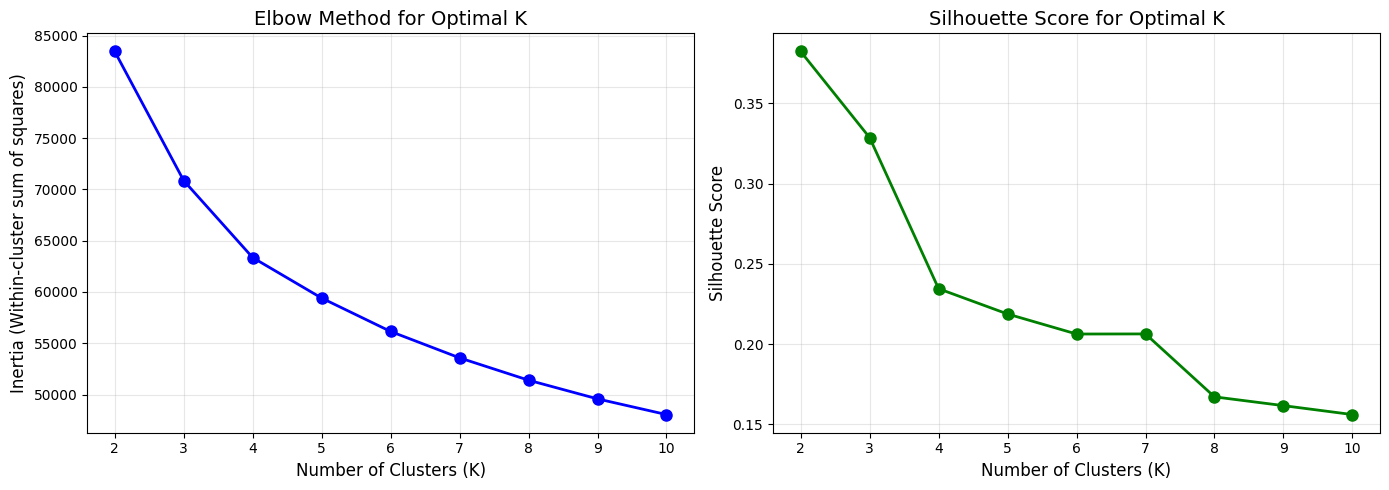


📊 RECOMMENDATION:
  Best K by Silhouette Score: 2
  Silhouette Score: 0.3822


In [8]:
# =====================================================
# STEP 4: FIND OPTIMAL K (Elbow Method + Silhouette Score)
# =====================================================

# Test K values from 2 to 10
k_range = range(2, 11)
inertias = []
silhouette_scores = []

print("Finding optimal K...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    print(f"  K={k}: Inertia={kmeans.inertia_:.0f}, Silhouette={silhouette_scores[-1]:.4f}")

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
axes[0].set_title('Elbow Method for Optimal K', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Silhouette score plot
axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score for Optimal K', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Recommend optimal K
best_k = k_range[np.argmax(silhouette_scores)]
print(f"\n📊 RECOMMENDATION:")
print(f"  Best K by Silhouette Score: {best_k}")
print(f"  Silhouette Score: {max(silhouette_scores):.4f}")

In [26]:
# =====================================================
# STEP 5: FINAL K-MEANS MODEL
# =====================================================

OPTIMAL_K = 3
print(f"Training K-Means with K={OPTIMAL_K}")

# Train final model
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to original dataframe
df['cluster'] = cluster_labels

print(f"\n✅ K-Means clustering complete!")
print(f"\nCluster Distribution:")
print(df['cluster'].value_counts().sort_index())

Training K-Means with K=3

✅ K-Means clustering complete!

Cluster Distribution:
cluster
0    3319
1    1448
2    2233
Name: count, dtype: int64


In [10]:
# =====================================================
# STEP 6: CLUSTER PROFILING - BUSINESS SEGMENTATION
# =====================================================
import seaborn as sns

# Key metrics for cluster profiling
profile_metrics = [
    'total_spent', 'orders_count', 'avg_order_value', 
    'days_since_last_purchase', 'total_events', 'avg_session_duration',
    'discount_usage_rate', 'failed_payment_rate', 'refund_rate',
    'session_duration_std', 'order_value_std'
]

# Calculate cluster means
cluster_profiles = df.groupby('cluster')[profile_metrics].mean().round(2)

print("=" * 80)
print("📊 CLUSTER PROFILES (Mean Values)")
print("=" * 80)
print(cluster_profiles.T)

# Calculate cluster medians (more robust to outliers)
print("\n" + "=" * 80)
print("📊 CLUSTER PROFILES (Median Values)")
print("=" * 80)
cluster_medians = df.groupby('cluster')[profile_metrics].median().round(2)
print(cluster_medians.T)

📊 CLUSTER PROFILES (Mean Values)
cluster                        0         1         2
total_spent                  NaN  38740.46  21370.51
orders_count                 NaN     36.27     24.06
avg_order_value              NaN   1056.50    883.01
days_since_last_purchase     NaN    402.63    446.93
total_events               74.48    130.90     72.36
avg_session_duration      709.00    686.76    713.38
discount_usage_rate          NaN      0.26      0.25
failed_payment_rate          NaN      0.08      0.08
refund_rate                  NaN      0.03      0.04
session_duration_std         NaN    331.22    323.45
order_value_std              NaN    453.65    421.98

📊 CLUSTER PROFILES (Median Values)
cluster                        0         1         2
total_spent                  NaN  32409.71  18093.44
orders_count                 NaN     34.00     21.00
avg_order_value              NaN   1125.89    827.52
days_since_last_purchase     NaN    413.00    453.00
total_events               69.

In [27]:
# =====================================================
# STEP 7: BUSINESS SEGMENT NAMING & DESCRIPTIONS
# =====================================================

# Create comprehensive cluster analysis
print("=" * 80)
print("🏷️ BUSINESS SEGMENT IDENTIFICATION")
print("=" * 80)

segment_analysis = []

for cluster_id in range(OPTIMAL_K):
    cluster_data = df[df['cluster'] == cluster_id]
    
    # Calculate key metrics
    avg_spent = cluster_data['total_spent'].mean()
    avg_orders = cluster_data['orders_count'].mean()
    avg_recency = cluster_data['days_since_last_purchase'].mean()
    avg_sessions = cluster_data['total_sessions'].mean() if 'total_sessions' in df.columns else cluster_data['total_events'].mean()
    avg_discount = cluster_data['discount_usage_rate'].mean()
    avg_session_dur = cluster_data['avg_session_duration'].mean()
    count = len(cluster_data)
    
    # FIX: Use actual total_spent values (not mean thresholds) 
    # Explicitly check for 0/NaN spend first to catch browsers/inactive
    actual_spent = cluster_data['total_spent'].fillna(0)
    pct_zero_spend = (actual_spent == 0).mean()  # % of customers with $0 spent
    
    # Determine segment name based on explicit behavior patterns
    if pct_zero_spend > 0.9:
        # 90%+ customers have zero spend → Non-buyers
        if avg_sessions > 10:
            segment_name = "👀 Active Browsers (Non-Buyers)"
            description = "High engagement, no purchases"
            strategy = "First purchase incentives, cart recovery"
            risk = "Conversion opportunity"
        else:
            segment_name = "😴 Inactive / Low Engagement"
            description = "Minimal activity overall"
            strategy = "Re-engagement emails, surveys"
            risk = "Very high churn risk"
    elif avg_spent > 25000 and avg_recency < 450:
        segment_name = "💎 VIP / High-Value Loyal"
        description = "High spend, recent activity, high engagement"
        strategy = "VIP program, exclusive offers, priority support"
        risk = "Low churn risk"
    elif avg_spent > 15000 and avg_recency < 500:
        segment_name = "🛒 Regular Active Buyers"
        description = "Consistent spending, regular purchases"
        strategy = "Loyalty rewards, cross-sell opportunities"
        risk = "Medium churn risk"
    elif avg_orders > 0 and avg_discount > 0.2:
        segment_name = "💰 Price Sensitive Buyers"
        description = "Buys mainly with discounts"
        strategy = "Strategic discounting, bundle offers"
        risk = "High price sensitivity"
    elif avg_orders > 0 and avg_recency > 500:
        segment_name = "⚠️ At-Risk / Dormant Buyers"
        description = "Past buyers, now inactive"
        strategy = "Win-back campaigns, reactivation offers"
        risk = "High churn risk"
    else:
        segment_name = "🛒 Regular Active Buyers"
        description = "Consistent spending, regular purchases"
        strategy = "Loyalty rewards, cross-sell opportunities"
        risk = "Medium churn risk"
    
    segment_analysis.append({
        'cluster': cluster_id,
        'segment_name': segment_name,
        'count': count,
        'pct_customers': round(count / len(df) * 100, 1),
        'avg_spent': round(avg_spent, 2),
        'avg_orders': round(avg_orders, 1),
        'avg_recency': round(avg_recency, 0),
        'avg_discount_rate': round(avg_discount * 100, 1),
        'pct_zero_spend': round(pct_zero_spend * 100, 1),
        'description': description,
        'strategy': strategy,
        'risk': risk
    })
    
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster_id}: {segment_name}")
    print(f"{'='*60}")
    print(f"  📈 Customers: {count:,} ({count/len(df)*100:.1f}%)")
    print(f"  💵 Avg Spend: {avg_spent:,.2f} EGP")
    print(f"  🔍 Zero-Spend Customers: {pct_zero_spend*100:.1f}%")
    print(f"  🛍️ Avg Orders: {avg_orders:.1f}")
    print(f"  📅 Avg Recency: {avg_recency:.0f} days")
    print(f"  🏷️ Discount Usage: {avg_discount*100:.1f}%")
    print(f"  📝 Description: {description}")
    print(f"  🎯 Strategy: {strategy}")
    print(f"  ⚠️ Risk Level: {risk}")

# Create summary DataFrame
segment_df = pd.DataFrame(segment_analysis)
print("\n" + "=" * 80)
print("📋 SEGMENT SUMMARY TABLE")
print("=" * 80)
display(segment_df[['cluster', 'segment_name', 'count', 'pct_customers', 'avg_spent', 'avg_orders', 'pct_zero_spend']])

🏷️ BUSINESS SEGMENT IDENTIFICATION

CLUSTER 0: 👀 Active Browsers (Non-Buyers)
  📈 Customers: 3,319 (47.4%)
  💵 Avg Spend: nan EGP
  🔍 Zero-Spend Customers: 100.0%
  🛍️ Avg Orders: nan
  📅 Avg Recency: nan days
  🏷️ Discount Usage: nan%
  📝 Description: High engagement, no purchases
  🎯 Strategy: First purchase incentives, cart recovery
  ⚠️ Risk Level: Conversion opportunity

CLUSTER 1: 💎 VIP / High-Value Loyal
  📈 Customers: 1,448 (20.7%)
  💵 Avg Spend: 38,740.46 EGP
  🔍 Zero-Spend Customers: 0.0%
  🛍️ Avg Orders: 36.3
  📅 Avg Recency: 403 days
  🏷️ Discount Usage: 26.2%
  📝 Description: High spend, recent activity, high engagement
  🎯 Strategy: VIP program, exclusive offers, priority support
  ⚠️ Risk Level: Low churn risk

CLUSTER 2: 🛒 Regular Active Buyers
  📈 Customers: 2,233 (31.9%)
  💵 Avg Spend: 21,370.51 EGP
  🔍 Zero-Spend Customers: 0.0%
  🛍️ Avg Orders: 24.1
  📅 Avg Recency: 447 days
  🏷️ Discount Usage: 25.3%
  📝 Description: Consistent spending, regular purchases
  🎯 Strat

,cluster,segment_name,count,pct_customers,avg_spent,avg_orders,pct_zero_spend
0,0,👀 Active Browsers (Non-Buyers),3319,47.4,NaN,NaN,100.0
1,1,💎 VIP / High-Value Loyal,1448,20.7,38740.46,36.3,0.0
2,2,🛒 Regular Active Buyers,2233,31.9,21370.51,24.1,0.0


📊 REVENUE & CUSTOMER DISTRIBUTION BY CLUSTER
 Cluster  Customers  % of Customers  Total Revenue  % of Revenue
       0       3319            47.4           0.00           0.0
       1       1448            20.7    56096192.40          54.0
       2       2233            31.9    47720339.16          46.0


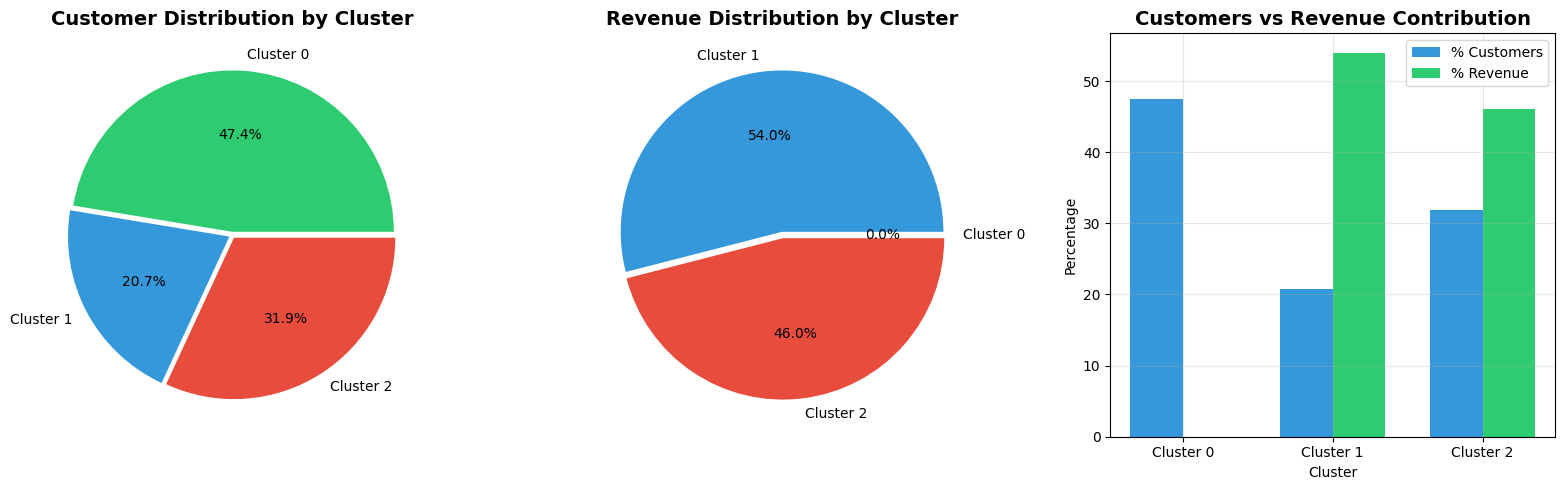


💡 KEY INSIGHT: PARETO ANALYSIS
  Cluster 1.0: 20.7% of customers → 54.0% of revenue
  Cluster 2.0: 31.9% of customers → 46.0% of revenue
  Cluster 0.0: 47.4% of customers → 0.0% of revenue


In [28]:
# =====================================================
# STEP 8: DISTRIBUTION ANALYSIS - REVENUE & CUSTOMER %
# =====================================================

# Calculate revenue contribution per cluster
df['total_spent_filled'] = df['total_spent'].fillna(0)
total_revenue = df['total_spent_filled'].sum()

distribution_analysis = []

for cluster_id in range(OPTIMAL_K):
    cluster_data = df[df['cluster'] == cluster_id]
    cluster_revenue = cluster_data['total_spent_filled'].sum()
    
    distribution_analysis.append({
        'Cluster': cluster_id,
        'Customers': len(cluster_data),
        '% of Customers': round(len(cluster_data) / len(df) * 100, 1),
        'Total Revenue': round(cluster_revenue, 2),
        '% of Revenue': round(cluster_revenue / total_revenue * 100, 1) if total_revenue > 0 else 0
    })

dist_df = pd.DataFrame(distribution_analysis)

print("=" * 80)
print("📊 REVENUE & CUSTOMER DISTRIBUTION BY CLUSTER")
print("=" * 80)
print(dist_df.to_string(index=False))

# Visualize the distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Customer distribution pie chart
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
axes[0].pie(dist_df['% of Customers'], labels=[f"Cluster {i}" for i in range(OPTIMAL_K)],
            autopct='%1.1f%%', colors=colors, explode=[0.02]*OPTIMAL_K)
axes[0].set_title('Customer Distribution by Cluster', fontsize=14, fontweight='bold')

# Revenue distribution pie chart
axes[1].pie(dist_df['% of Revenue'], labels=[f"Cluster {i}" for i in range(OPTIMAL_K)],
            autopct='%1.1f%%', colors=colors, explode=[0.02]*OPTIMAL_K)
axes[1].set_title('Revenue Distribution by Cluster', fontsize=14, fontweight='bold')

# Bar comparison
x = np.arange(OPTIMAL_K)
width = 0.35
bars1 = axes[2].bar(x - width/2, dist_df['% of Customers'], width, label='% Customers', color='#3498db')
bars2 = axes[2].bar(x + width/2, dist_df['% of Revenue'], width, label='% Revenue', color='#2ecc71')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Percentage')
axes[2].set_title('Customers vs Revenue Contribution', fontsize=14, fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels([f'Cluster {i}' for i in range(OPTIMAL_K)])
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Key insight
print("\n" + "=" * 80)
print("💡 KEY INSIGHT: PARETO ANALYSIS")
print("=" * 80)
# Sort by revenue contribution
sorted_dist = dist_df.sort_values('% of Revenue', ascending=False)
cumulative_revenue = sorted_dist['% of Revenue'].cumsum().values
cumulative_customers = sorted_dist['% of Customers'].cumsum().values

for i, row in sorted_dist.iterrows():
    print(f"  Cluster {row['Cluster']}: {row['% of Customers']:.1f}% of customers → {row['% of Revenue']:.1f}% of revenue")

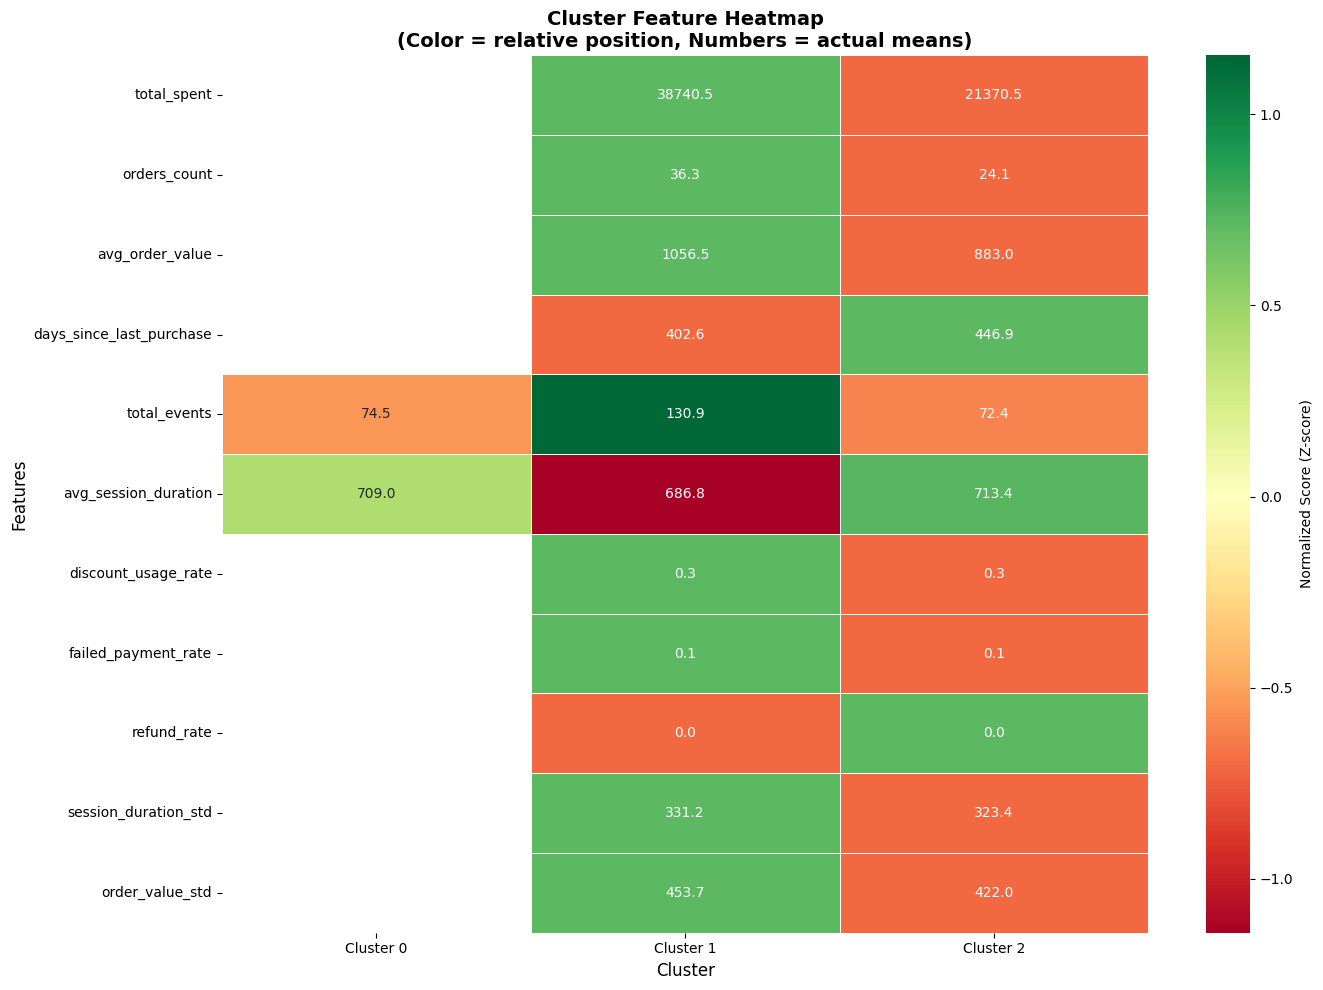


💡 HEATMAP INTERPRETATION:
  🟢 Green = Above average for that feature
  🔴 Red = Below average for that feature
  Numbers show actual mean values


In [13]:
# =====================================================
# STEP 9: VISUAL ANALYSIS - HEATMAP OF CLUSTER PROFILES
# =====================================================

# Normalize cluster means for heatmap (z-score within each feature)
cluster_means = df.groupby('cluster')[profile_metrics].mean()
cluster_means_normalized = (cluster_means - cluster_means.mean()) / cluster_means.std()

# Create heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(cluster_means_normalized.T, 
            annot=cluster_means.T.round(1).values,  # Show actual values
            fmt='', 
            cmap='RdYlGn',
            center=0,
            linewidths=0.5,
            cbar_kws={'label': 'Normalized Score (Z-score)'},
            xticklabels=[f'Cluster {i}' for i in range(OPTIMAL_K)])

plt.title('Cluster Feature Heatmap\n(Color = relative position, Numbers = actual means)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

print("\n💡 HEATMAP INTERPRETATION:")
print("  🟢 Green = Above average for that feature")
print("  🔴 Red = Below average for that feature")
print("  Numbers show actual mean values")

C:\Users\alyah\AppData\Local\Temp\ipykernel_30700\485374189.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='cluster', y=feature, ax=axes[idx], palette='viridis')
C:\Users\alyah\AppData\Local\Temp\ipykernel_30700\485374189.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='cluster', y=feature, ax=axes[idx], palette='viridis')
C:\Users\alyah\AppData\Local\Temp\ipykernel_30700\485374189.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='cluster', y=feature, ax=axes[idx], palette='virid

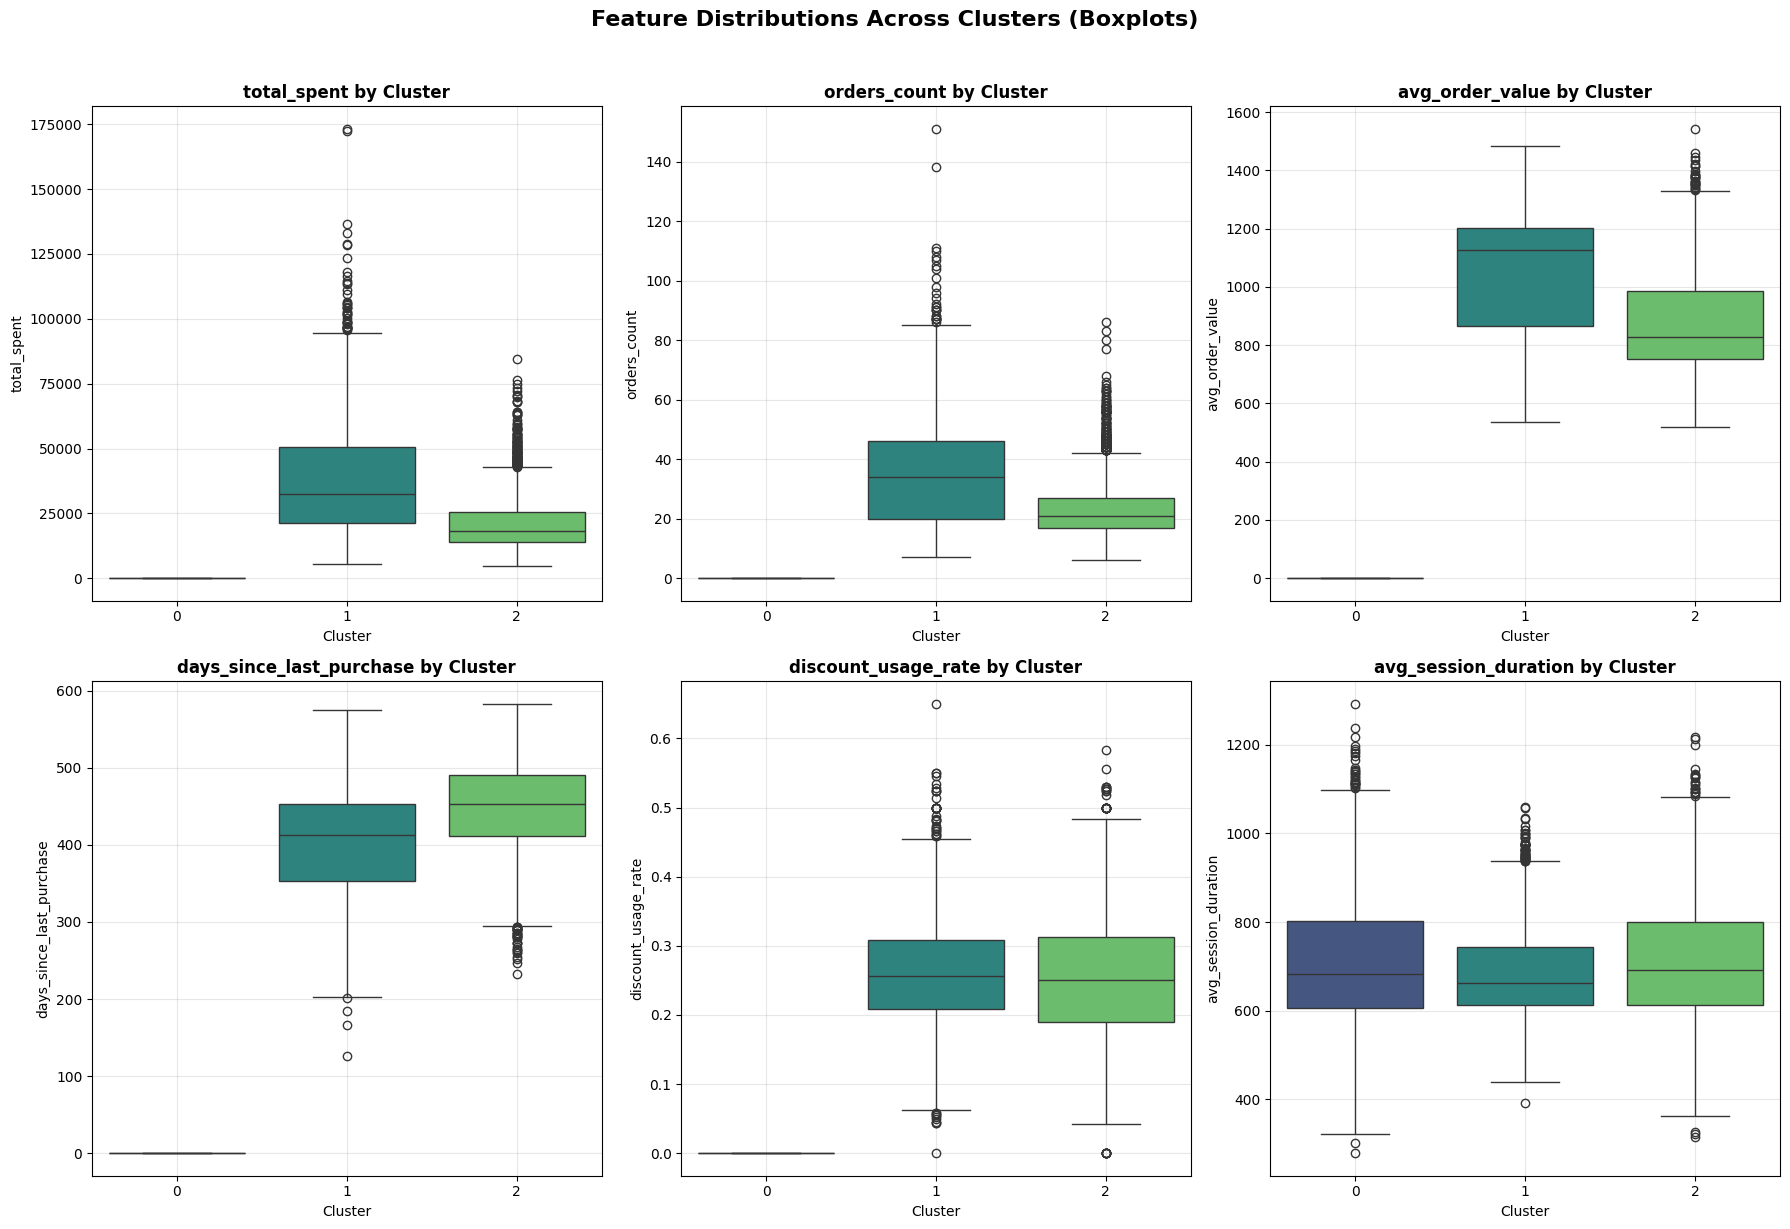


💡 BOXPLOT INSIGHTS:
  - Compare medians (horizontal line) across clusters
  - Check spread (box height) for variance within cluster
  - Outliers (dots) show extreme customers


In [14]:
# =====================================================
# STEP 10: BOXPLOTS - FEATURE DISTRIBUTIONS PER CLUSTER
# =====================================================

# Key features for boxplot analysis
boxplot_features = ['total_spent', 'orders_count', 'avg_order_value', 
                    'days_since_last_purchase', 'discount_usage_rate', 'avg_session_duration']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, feature in enumerate(boxplot_features):
    # Fill NaN for visualization
    df_plot = df.copy()
    df_plot[feature] = df_plot[feature].fillna(0)
    
    sns.boxplot(data=df_plot, x='cluster', y=feature, ax=axes[idx], palette='viridis')
    axes[idx].set_title(f'{feature} by Cluster', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Cluster')
    axes[idx].set_ylabel(feature)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Feature Distributions Across Clusters (Boxplots)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 BOXPLOT INSIGHTS:")
print("  - Compare medians (horizontal line) across clusters")
print("  - Check spread (box height) for variance within cluster")
print("  - Outliers (dots) show extreme customers")

C:\Users\alyah\AppData\Local\Temp\ipykernel_30700\2280776089.py:43: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\alyah\VC\first_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


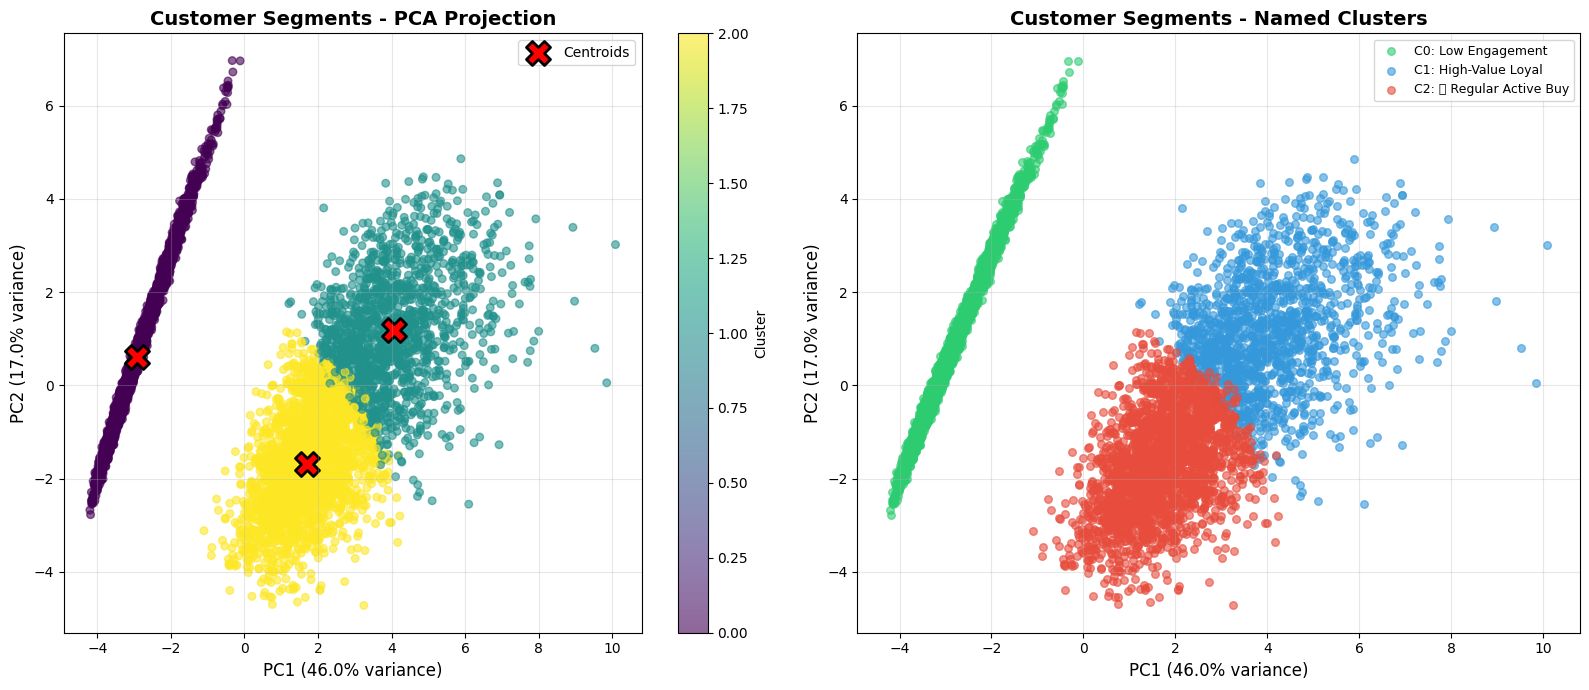


📊 PCA explains 63.0% of total variance
  PC1: 46.0%
  PC2: 17.0%


In [15]:
# =====================================================
# STEP 11: PCA VISUALIZATION (2D Cluster View)
# =====================================================
from sklearn.decomposition import PCA

# Apply PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Clusters with centroids
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, 
                          cmap='viridis', alpha=0.6, s=30)
# Add centroids
centers_pca = pca.transform(kmeans_final.cluster_centers_)
axes[0].scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X', 
                s=300, edgecolors='black', linewidths=2, label='Centroids')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
axes[0].set_title('Customer Segments - PCA Projection', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[0], label='Cluster')

# Plot 2: Clusters with segment names
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
for i in range(OPTIMAL_K):
    mask = cluster_labels == i
    segment_name = segment_df[segment_df['cluster'] == i]['segment_name'].values[0]
    # Truncate name for legend
    short_name = segment_name.split('/')[-1].strip() if '/' in segment_name else segment_name
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[i], 
                    alpha=0.6, s=30, label=f'C{i}: {short_name[:20]}')

axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
axes[1].set_title('Customer Segments - Named Clusters', fontsize=14, fontweight='bold')
axes[1].legend(loc='best', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 PCA explains {pca.explained_variance_ratio_.sum()*100:.1f}% of total variance")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")

C:\Users\alyah\AppData\Local\Temp\ipykernel_30700\397543698.py:34: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\alyah\AppData\Local\Temp\ipykernel_30700\397543698.py:34: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\alyah\VC\first_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\alyah\VC\first_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


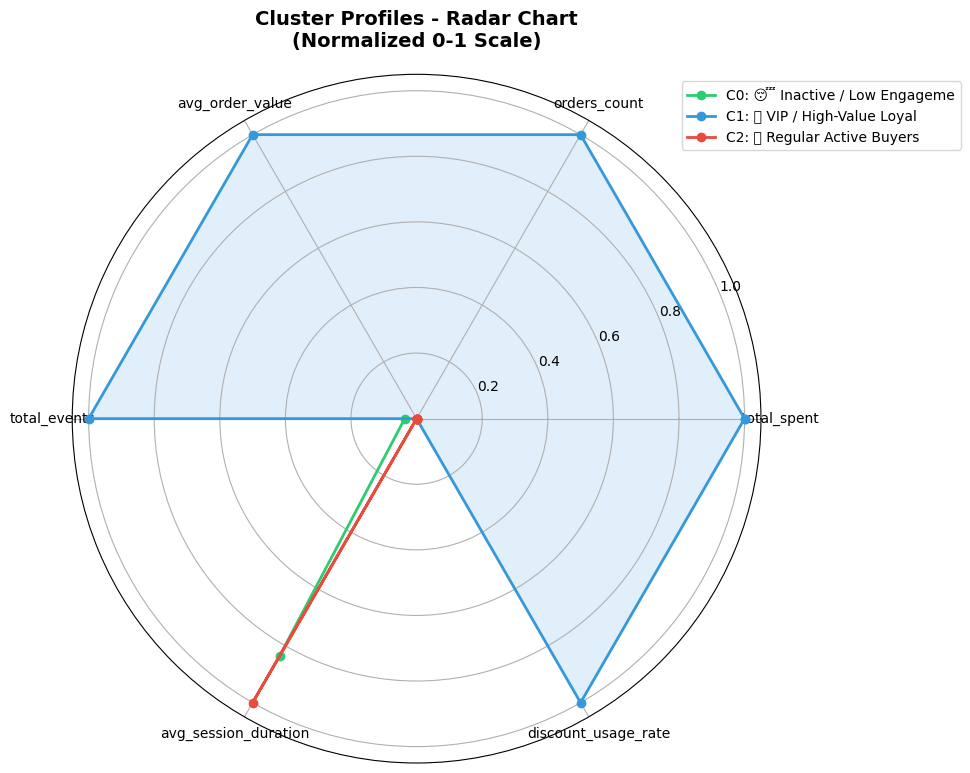


💡 RADAR CHART INTERPRETATION:
  - Each axis represents a normalized feature (0-1 scale)
  - Larger area = higher values across metrics
  - Shape differences reveal cluster characteristics


In [16]:
# =====================================================
# STEP 12: RADAR CHART - CLUSTER COMPARISON
# =====================================================

# Normalize features for radar chart (0-1 scale)
radar_features = ['total_spent', 'orders_count', 'avg_order_value', 
                  'total_events', 'avg_session_duration', 'discount_usage_rate']

cluster_means_radar = df.groupby('cluster')[radar_features].mean()

# Normalize to 0-1 scale for each feature
cluster_means_norm = (cluster_means_radar - cluster_means_radar.min()) / (cluster_means_radar.max() - cluster_means_radar.min())

# Create radar chart
angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]  # Complete the loop

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
for cluster_id in range(OPTIMAL_K):
    values = cluster_means_norm.loc[cluster_id].tolist()
    values += values[:1]  # Complete the loop
    segment_name = segment_df[segment_df['cluster'] == cluster_id]['segment_name'].values[0]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'C{cluster_id}: {segment_name[:25]}', color=colors[cluster_id])
    ax.fill(angles, values, alpha=0.15, color=colors[cluster_id])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, fontsize=10)
ax.set_title('Cluster Profiles - Radar Chart\n(Normalized 0-1 Scale)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax.grid(True)

plt.tight_layout()
plt.show()

print("\n💡 RADAR CHART INTERPRETATION:")
print("  - Each axis represents a normalized feature (0-1 scale)")
print("  - Larger area = higher values across metrics")
print("  - Shape differences reveal cluster characteristics")

) missing from font(s) DejaVu Sans.pykernel_30700\665443979.py:44: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans.nv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


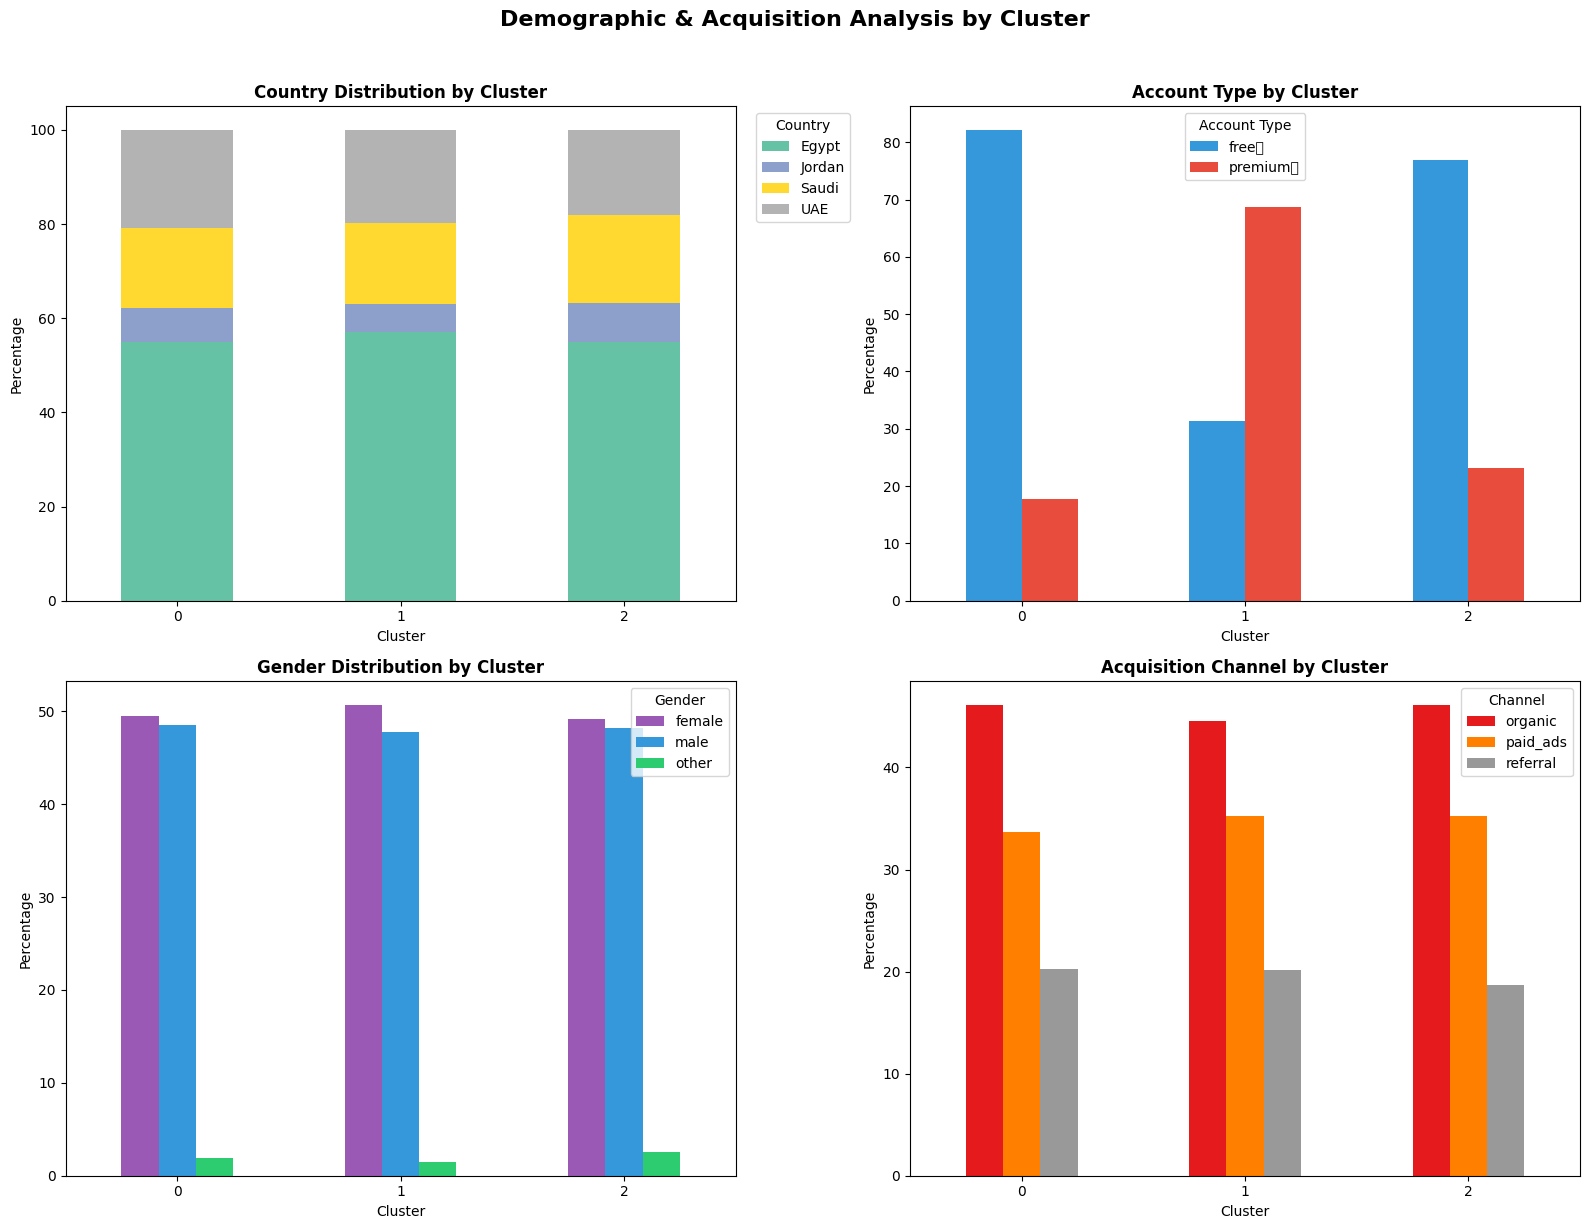

In [17]:
# =====================================================
# STEP 13: DEMOGRAPHIC ANALYSIS PER CLUSTER
# =====================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Country distribution per cluster
country_cluster = pd.crosstab(df['cluster'], df['country'], normalize='index') * 100
country_cluster.plot(kind='bar', stacked=True, ax=axes[0, 0], colormap='Set2')
axes[0, 0].set_title('Country Distribution by Cluster', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Cluster')
axes[0, 0].set_ylabel('Percentage')
axes[0, 0].legend(title='Country', bbox_to_anchor=(1.02, 1))
axes[0, 0].tick_params(axis='x', rotation=0)

# 2. Account type distribution per cluster
account_cluster = pd.crosstab(df['cluster'], df['account_type'], normalize='index') * 100
account_cluster.plot(kind='bar', ax=axes[0, 1], color=['#3498db', '#e74c3c'])
axes[0, 1].set_title('Account Type by Cluster', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Percentage')
axes[0, 1].legend(title='Account Type')
axes[0, 1].tick_params(axis='x', rotation=0)

# 3. Gender distribution per cluster
gender_cluster = pd.crosstab(df['cluster'], df['gender'], normalize='index') * 100
gender_cluster.plot(kind='bar', ax=axes[1, 0], color=['#9b59b6', '#3498db', '#2ecc71'])
axes[1, 0].set_title('Gender Distribution by Cluster', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Percentage')
axes[1, 0].legend(title='Gender')
axes[1, 0].tick_params(axis='x', rotation=0)

# 4. Acquisition channel per cluster
channel_cluster = pd.crosstab(df['cluster'], df['acquisition_channel'], normalize='index') * 100
channel_cluster.plot(kind='bar', ax=axes[1, 1], colormap='Set1')
axes[1, 1].set_title('Acquisition Channel by Cluster', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Percentage')
axes[1, 1].legend(title='Channel')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.suptitle('Demographic & Acquisition Analysis by Cluster', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [18]:
# =====================================================
# STEP 14: STRATEGIC RECOMMENDATIONS & ACTION ITEMS
# =====================================================

print("=" * 80)
print("🎯 STRATEGIC RECOMMENDATIONS BY SEGMENT")
print("=" * 80)

recommendations = {
    'retention': [],
    'vip_program': [],
    'churn_risk': [],
    'discount_strategy': []
}

for cluster_id in range(OPTIMAL_K):
    cluster_data = df[df['cluster'] == cluster_id]
    segment_info = segment_df[segment_df['cluster'] == cluster_id].iloc[0]
    
    avg_spent = cluster_data['total_spent'].mean()
    avg_recency = cluster_data['days_since_last_purchase'].mean()
    avg_discount = cluster_data['discount_usage_rate'].mean()
    count = len(cluster_data)
    
    print(f"\n{'='*60}")
    print(f"📌 CLUSTER {cluster_id}: {segment_info['segment_name']}")
    print(f"{'='*60}")
    print(f"   Customers: {count:,} | Avg Spend: {avg_spent:,.0f} EGP | Recency: {avg_recency:.0f} days")
    
    # Categorize for action
    if avg_spent > 20000 and avg_recency < 480:
        print("\n   ✅ ACTION: VIP PROGRAM CANDIDATE")
        print("   - Enroll in exclusive VIP tier")
        print("   - Early access to new products")
        print("   - Personal account manager")
        print("   - Priority customer support")
        recommendations['vip_program'].append(cluster_id)
        
    elif avg_spent > 0 and avg_recency > 480:
        print("\n   ⚠️ ACTION: RETENTION CAMPAIGN NEEDED")
        print("   - Send win-back email sequence")
        print("   - Offer 'We miss you' discount (15-20%)")
        print("   - Show personalized product recommendations")
        print("   - Survey to understand why they left")
        recommendations['retention'].append(cluster_id)
        recommendations['churn_risk'].append(cluster_id)
        
    elif avg_discount > 0.25:
        print("\n   💰 ACTION: STRATEGIC DISCOUNT APPROACH")
        print("   - Use tiered discounts (spend more, save more)")
        print("   - Bundle offers instead of flat discounts")
        print("   - Loyalty points system to reduce discount dependency")
        print("   - Test reducing discount frequency gradually")
        recommendations['discount_strategy'].append(cluster_id)
        
    elif avg_spent == 0:
        print("\n   🎯 ACTION: CONVERSION CAMPAIGN")
        print("   - First purchase incentive (free shipping/10% off)")
        print("   - Cart abandonment recovery emails")
        print("   - Showcase best-sellers and social proof")
        print("   - Simplify checkout process")
        
    else:
        print("\n   📈 ACTION: GROWTH OPPORTUNITY")
        print("   - Cross-sell and upsell campaigns")
        print("   - Loyalty program enrollment")
        print("   - Personalized recommendations")
        print("   - Encourage reviews for rewards")

print("\n" + "=" * 80)
print("📋 SUMMARY: ACTION PRIORITY MATRIX")
print("=" * 80)
print(f"\n🏆 VIP Program Candidates: Clusters {recommendations['vip_program']}")
print(f"⚠️ Retention Campaigns Needed: Clusters {recommendations['retention']}")
print(f"🔴 High Churn Risk: Clusters {recommendations['churn_risk']}")
print(f"💰 Discount Strategy Review: Clusters {recommendations['discount_strategy']}")

🎯 STRATEGIC RECOMMENDATIONS BY SEGMENT

📌 CLUSTER 0: 😴 Inactive / Low Engagement
   Customers: 3,319 | Avg Spend: nan EGP | Recency: nan days

   📈 ACTION: GROWTH OPPORTUNITY
   - Cross-sell and upsell campaigns
   - Loyalty program enrollment
   - Personalized recommendations
   - Encourage reviews for rewards

📌 CLUSTER 1: 💎 VIP / High-Value Loyal
   Customers: 1,448 | Avg Spend: 38,740 EGP | Recency: 403 days

   ✅ ACTION: VIP PROGRAM CANDIDATE
   - Enroll in exclusive VIP tier
   - Early access to new products
   - Personal account manager
   - Priority customer support

📌 CLUSTER 2: 🛒 Regular Active Buyers
   Customers: 2,233 | Avg Spend: 21,371 EGP | Recency: 447 days

   ✅ ACTION: VIP PROGRAM CANDIDATE
   - Enroll in exclusive VIP tier
   - Early access to new products
   - Personal account manager
   - Priority customer support

📋 SUMMARY: ACTION PRIORITY MATRIX

🏆 VIP Program Candidates: Clusters [1, 2]
⚠️ Retention Campaigns Needed: Clusters []
🔴 High Churn Risk: Clusters []


💰 CUSTOMER LIFETIME VALUE (CLV) ANALYSIS
          Avg CLV  Median CLV    Total CLV  Avg Order  Purchases/Month  \
cluster                                                                  
0            0.00        0.00         0.00        NaN             0.00   
1        27028.83    22629.81  39137744.07    1056.50             2.11   
2        14777.73    12547.31  32998665.97     883.01             1.39   

         Tenure (days)  
cluster                 
0               518.47  
1               517.01  
2               522.21  


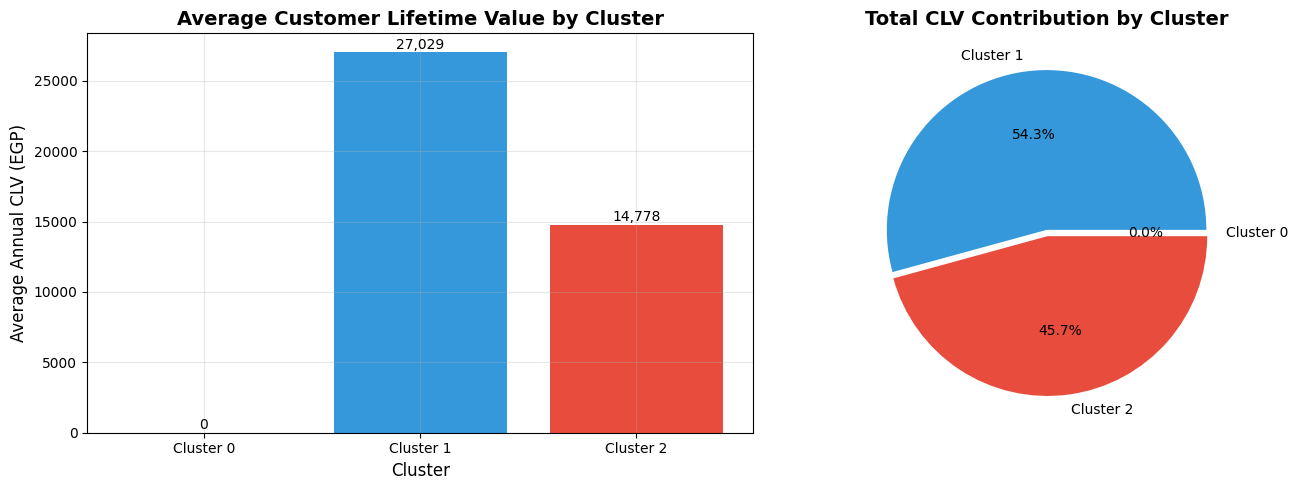


💡 CLV-BASED INVESTMENT PRIORITY:
  1. Cluster 1 (💎 VIP / High-Value Loyal): 27,029 EGP annual CLV
  2. Cluster 2 (🛒 Regular Active Buyers): 14,778 EGP annual CLV
  3. Cluster 0 (👀 Active Browsers (Non-Bu): 0 EGP annual CLV


In [29]:
# =====================================================
# STEP 15: CUSTOMER LIFETIME VALUE (CLV) ESTIMATION
# =====================================================

# Simple CLV estimation per cluster
# CLV = Avg Order Value × Purchase Frequency × Customer Lifespan

df['purchase_frequency'] = df['orders_count'].fillna(0) / (df['customer_tenure_days'] / 30)  # per month
df['estimated_clv'] = df['avg_order_value'].fillna(0) * df['purchase_frequency'] * 12  # annualized

clv_analysis = df.groupby('cluster').agg({
    'estimated_clv': ['mean', 'median', 'sum'],
    'avg_order_value': 'mean',
    'purchase_frequency': 'mean',
    'customer_tenure_days': 'mean'
}).round(2)

clv_analysis.columns = ['Avg CLV', 'Median CLV', 'Total CLV', 'Avg Order', 'Purchases/Month', 'Tenure (days)']

print("=" * 80)
print("💰 CUSTOMER LIFETIME VALUE (CLV) ANALYSIS")
print("=" * 80)
print(clv_analysis)

# Visualize CLV
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average CLV by cluster
clv_by_cluster = df.groupby('cluster')['estimated_clv'].mean()
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
bars = axes[0].bar(range(OPTIMAL_K), clv_by_cluster.values, color=colors)
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('Average Annual CLV (EGP)', fontsize=12)
axes[0].set_title('Average Customer Lifetime Value by Cluster', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(OPTIMAL_K))
axes[0].set_xticklabels([f'Cluster {i}' for i in range(OPTIMAL_K)])
# Add value labels
for bar, val in zip(bars, clv_by_cluster.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Total CLV contribution (pie)
total_clv = df.groupby('cluster')['estimated_clv'].sum()
axes[1].pie(total_clv.values, labels=[f'Cluster {i}' for i in range(OPTIMAL_K)],
            autopct='%1.1f%%', colors=colors, explode=[0.02]*OPTIMAL_K)
axes[1].set_title('Total CLV Contribution by Cluster', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Investment priority
print("\n💡 CLV-BASED INVESTMENT PRIORITY:")
sorted_clv = clv_by_cluster.sort_values(ascending=False)
for rank, (cluster, clv) in enumerate(sorted_clv.items(), 1):
    segment = segment_df[segment_df['cluster'] == cluster]['segment_name'].values[0]
    print(f"  {rank}. Cluster {cluster} ({segment[:25]}): {clv:,.0f} EGP annual CLV")

In [20]:
# =====================================================
# STEP 16: FEATURE IMPORTANCE - WHAT DEFINES EACH CLUSTER?
# =====================================================

# Calculate feature importance using cluster centers distance from overall mean
cluster_centers_df = pd.DataFrame(
    scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=feature_columns
)

overall_mean = df_features[feature_columns].mean()

# For each cluster, find the most distinctive features
print("=" * 80)
print("🔍 DISTINCTIVE FEATURES PER CLUSTER")
print("=" * 80)
print("(Features that differ most from overall average)")

for cluster_id in range(OPTIMAL_K):
    cluster_center = cluster_centers_df.iloc[cluster_id]
    
    # Calculate z-scores (how many std from mean)
    diff_from_mean = (cluster_center - overall_mean) / df_features[feature_columns].std()
    
    # Get top 5 distinctive features (highest absolute z-score)
    top_features = diff_from_mean.abs().sort_values(ascending=False).head(5)
    
    segment = segment_df[segment_df['cluster'] == cluster_id]['segment_name'].values[0]
    print(f"\n📌 Cluster {cluster_id}: {segment}")
    print("-" * 50)
    
    for feature, zscore in top_features.items():
        actual_diff = diff_from_mean[feature]
        direction = "↑ HIGHER" if actual_diff > 0 else "↓ LOWER"
        print(f"   {feature}: {direction} than average (z={actual_diff:.2f})")

🔍 DISTINCTIVE FEATURES PER CLUSTER
(Features that differ most from overall average)

📌 Cluster 0: 😴 Inactive / Low Engagement
--------------------------------------------------
   order_value_std: ↓ LOWER than average (z=-6.10)
   avg_items_per_order: ↓ LOWER than average (z=-4.83)
   avg_order_value: ↓ LOWER than average (z=-4.60)
   session_duration_std: ↓ LOWER than average (z=-4.42)
   discount_usage_rate: ↓ LOWER than average (z=-2.90)

📌 Cluster 1: 💎 VIP / High-Value Loyal
--------------------------------------------------
   total_events: ↑ HIGHER than average (z=1.32)
   active_days: ↑ HIGHER than average (z=1.29)
   total_sessions: ↑ HIGHER than average (z=1.29)
   browse_events: ↑ HIGHER than average (z=1.28)
   purchase_events: ↑ HIGHER than average (z=1.15)

📌 Cluster 2: 🛒 Regular Active Buyers
--------------------------------------------------
   purchase_events: ↑ HIGHER than average (z=0.50)
   browse_events: ↓ LOWER than average (z=-0.41)
   active_days: ↓ LOWER than av

C:\Users\alyah\AppData\Local\Temp\ipykernel_30700\162019795.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
c:\Users\alyah\VC\first_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\alyah\VC\first_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\alyah\VC\first_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


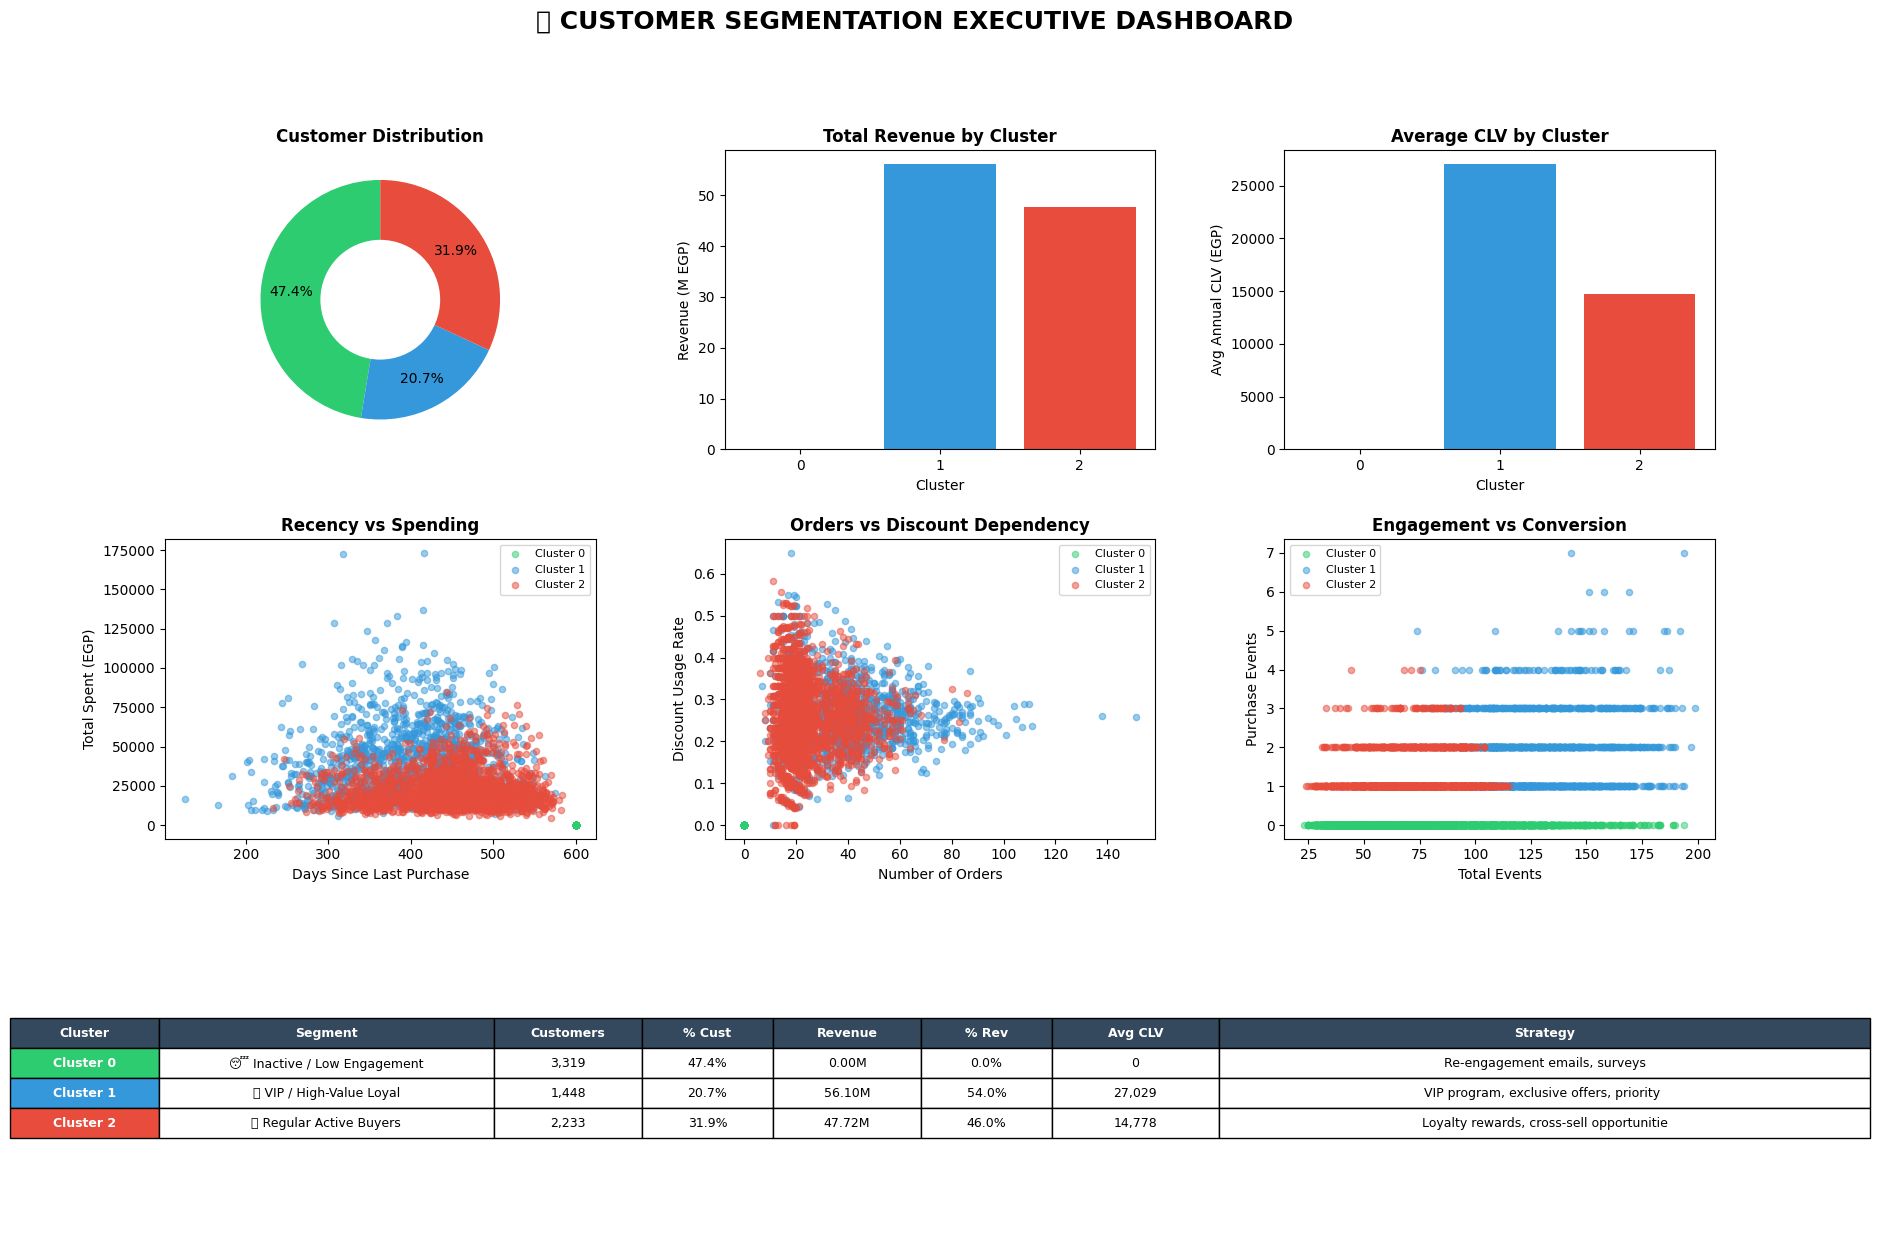


✅ Analysis Complete! Dashboard generated successfully.


In [21]:
# =====================================================
# STEP 17: FINAL EXECUTIVE SUMMARY DASHBOARD
# =====================================================

fig = plt.figure(figsize=(20, 14))

# Create grid layout
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Cluster Distribution (Donut chart)
ax1 = fig.add_subplot(gs[0, 0])
sizes = df['cluster'].value_counts().sort_index().values
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
wedges, texts, autotexts = ax1.pie(sizes, colors=colors, autopct='%1.1f%%',
                                    pctdistance=0.75, startangle=90)
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
ax1.add_patch(centre_circle)
ax1.set_title('Customer Distribution', fontsize=12, fontweight='bold')

# 2. Revenue by Cluster (Bar)
ax2 = fig.add_subplot(gs[0, 1])
revenue_by_cluster = df.groupby('cluster')['total_spent_filled'].sum() / 1000000
bars = ax2.bar(range(OPTIMAL_K), revenue_by_cluster.values, color=colors)
ax2.set_xlabel('Cluster')
ax2.set_ylabel('Revenue (M EGP)')
ax2.set_title('Total Revenue by Cluster', fontsize=12, fontweight='bold')
ax2.set_xticks(range(OPTIMAL_K))

# 3. CLV by Cluster (Bar)
ax3 = fig.add_subplot(gs[0, 2])
clv_by_cluster = df.groupby('cluster')['estimated_clv'].mean()
bars = ax3.bar(range(OPTIMAL_K), clv_by_cluster.values, color=colors)
ax3.set_xlabel('Cluster')
ax3.set_ylabel('Avg Annual CLV (EGP)')
ax3.set_title('Average CLV by Cluster', fontsize=12, fontweight='bold')
ax3.set_xticks(range(OPTIMAL_K))

# 4. Recency vs Spending Scatter
ax4 = fig.add_subplot(gs[1, 0])
for i in range(OPTIMAL_K):
    mask = df['cluster'] == i
    ax4.scatter(df.loc[mask, 'days_since_last_purchase'].fillna(600), 
                df.loc[mask, 'total_spent_filled'], 
                c=colors[i], alpha=0.5, s=20, label=f'Cluster {i}')
ax4.set_xlabel('Days Since Last Purchase')
ax4.set_ylabel('Total Spent (EGP)')
ax4.set_title('Recency vs Spending', fontsize=12, fontweight='bold')
ax4.legend(fontsize=8)

# 5. Orders vs Discount Usage
ax5 = fig.add_subplot(gs[1, 1])
for i in range(OPTIMAL_K):
    mask = df['cluster'] == i
    ax5.scatter(df.loc[mask, 'orders_count'].fillna(0), 
                df.loc[mask, 'discount_usage_rate'].fillna(0), 
                c=colors[i], alpha=0.5, s=20, label=f'Cluster {i}')
ax5.set_xlabel('Number of Orders')
ax5.set_ylabel('Discount Usage Rate')
ax5.set_title('Orders vs Discount Dependency', fontsize=12, fontweight='bold')
ax5.legend(fontsize=8)

# 6. Sessions vs Purchases
ax6 = fig.add_subplot(gs[1, 2])
for i in range(OPTIMAL_K):
    mask = df['cluster'] == i
    ax6.scatter(df.loc[mask, 'total_events'], 
                df.loc[mask, 'purchase_events'].fillna(0), 
                c=colors[i], alpha=0.5, s=20, label=f'Cluster {i}')
ax6.set_xlabel('Total Events')
ax6.set_ylabel('Purchase Events')
ax6.set_title('Engagement vs Conversion', fontsize=12, fontweight='bold')
ax6.legend(fontsize=8)

# 7-9: Summary Table
ax7 = fig.add_subplot(gs[2, :])
ax7.axis('off')

# Create summary table
summary_data = []
for i in range(OPTIMAL_K):
    cluster_data = df[df['cluster'] == i]
    segment = segment_df[segment_df['cluster'] == i]['segment_name'].values[0]
    summary_data.append([
        f'Cluster {i}',
        segment[:30],
        f"{len(cluster_data):,}",
        f"{len(cluster_data)/len(df)*100:.1f}%",
        f"{cluster_data['total_spent_filled'].sum()/1000000:.2f}M",
        f"{cluster_data['total_spent_filled'].sum()/total_revenue*100:.1f}%",
        f"{cluster_data['estimated_clv'].mean():,.0f}",
        segment_df[segment_df['cluster'] == i]['strategy'].values[0][:40]
    ])

table = ax7.table(cellText=summary_data,
                  colLabels=['Cluster', 'Segment', 'Customers', '% Cust', 'Revenue', '% Rev', 'Avg CLV', 'Strategy'],
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.08, 0.18, 0.08, 0.07, 0.08, 0.07, 0.09, 0.35])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)

# Color the header
for i in range(8):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(color='white', fontweight='bold')

# Color cluster rows
for i in range(1, OPTIMAL_K + 1):
    table[(i, 0)].set_facecolor(colors[i-1])
    table[(i, 0)].set_text_props(color='white', fontweight='bold')

plt.suptitle('📊 CUSTOMER SEGMENTATION EXECUTIVE DASHBOARD', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n✅ Analysis Complete! Dashboard generated successfully.")

In [30]:
# =====================================================
# STEP 18: BEHAVIORAL DRIFT ANALYSIS OVER TIME
# =====================================================

# We need to connect to MySQL to get time-based order data for drift analysis
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",      
    user="root",
    password="susboi2213",
    database="e_commerce"
)

# Get monthly order data with customer info
query = """
SELECT 
    o.customer_id,
    DATE_FORMAT(o.order_date, '%Y-%m') as month,
    COUNT(*) as monthly_orders,
    SUM(o.order_value) as monthly_spent,
    AVG(o.order_value) as avg_order_value,
    SUM(CASE WHEN o.discount_applied = 1 THEN 1 ELSE 0 END) / COUNT(*) as discount_rate
FROM orders o
GROUP BY o.customer_id, DATE_FORMAT(o.order_date, '%Y-%m')
ORDER BY month;
"""

monthly_orders = pd.read_sql(query, conn)

# Get monthly events data
query_events = """
SELECT 
    customer_id,
    DATE_FORMAT(event_date, '%Y-%m') as month,
    COUNT(*) as monthly_events,
    AVG(session_duration_sec) as avg_session_duration
FROM events
GROUP BY customer_id, DATE_FORMAT(event_date, '%Y-%m')
ORDER BY month;
"""

monthly_events = pd.read_sql(query_events, conn)
conn.close()

# Merge with cluster labels
customer_clusters = df[['customer_id', 'cluster']].copy()
monthly_orders = monthly_orders.merge(customer_clusters, on='customer_id', how='left')
monthly_events = monthly_events.merge(customer_clusters, on='customer_id', how='left')

print(f"Monthly order data: {len(monthly_orders)} rows")
print(f"Monthly event data: {len(monthly_events)} rows")
print(f"Date range: {monthly_orders['month'].min()} to {monthly_orders['month'].max()}")

C:\Users\alyah\AppData\Local\Temp\ipykernel_34296\3069989622.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthly_orders = pd.read_sql(query, conn)
C:\Users\alyah\AppData\Local\Temp\ipykernel_34296\3069989622.py:43: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthly_events = pd.read_sql(query_events, conn)


Monthly order data: 5081 rows
Monthly event data: 36577 rows
Date range: 2024-07 to 2025-10


C:\Users\alyah\AppData\Local\Temp\ipykernel_34296\2489679146.py:127: UserWarning: Glyph 128064 (\N{EYES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\alyah\AppData\Local\Temp\ipykernel_34296\2489679146.py:127: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\alyah\AppData\Local\Temp\ipykernel_34296\2489679146.py:127: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\alyah\AppData\Local\Temp\ipykernel_34296\2489679146.py:127: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\alyah\VC\first_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128064 (\N{EYES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\alyah\VC\first_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128142 (\N{

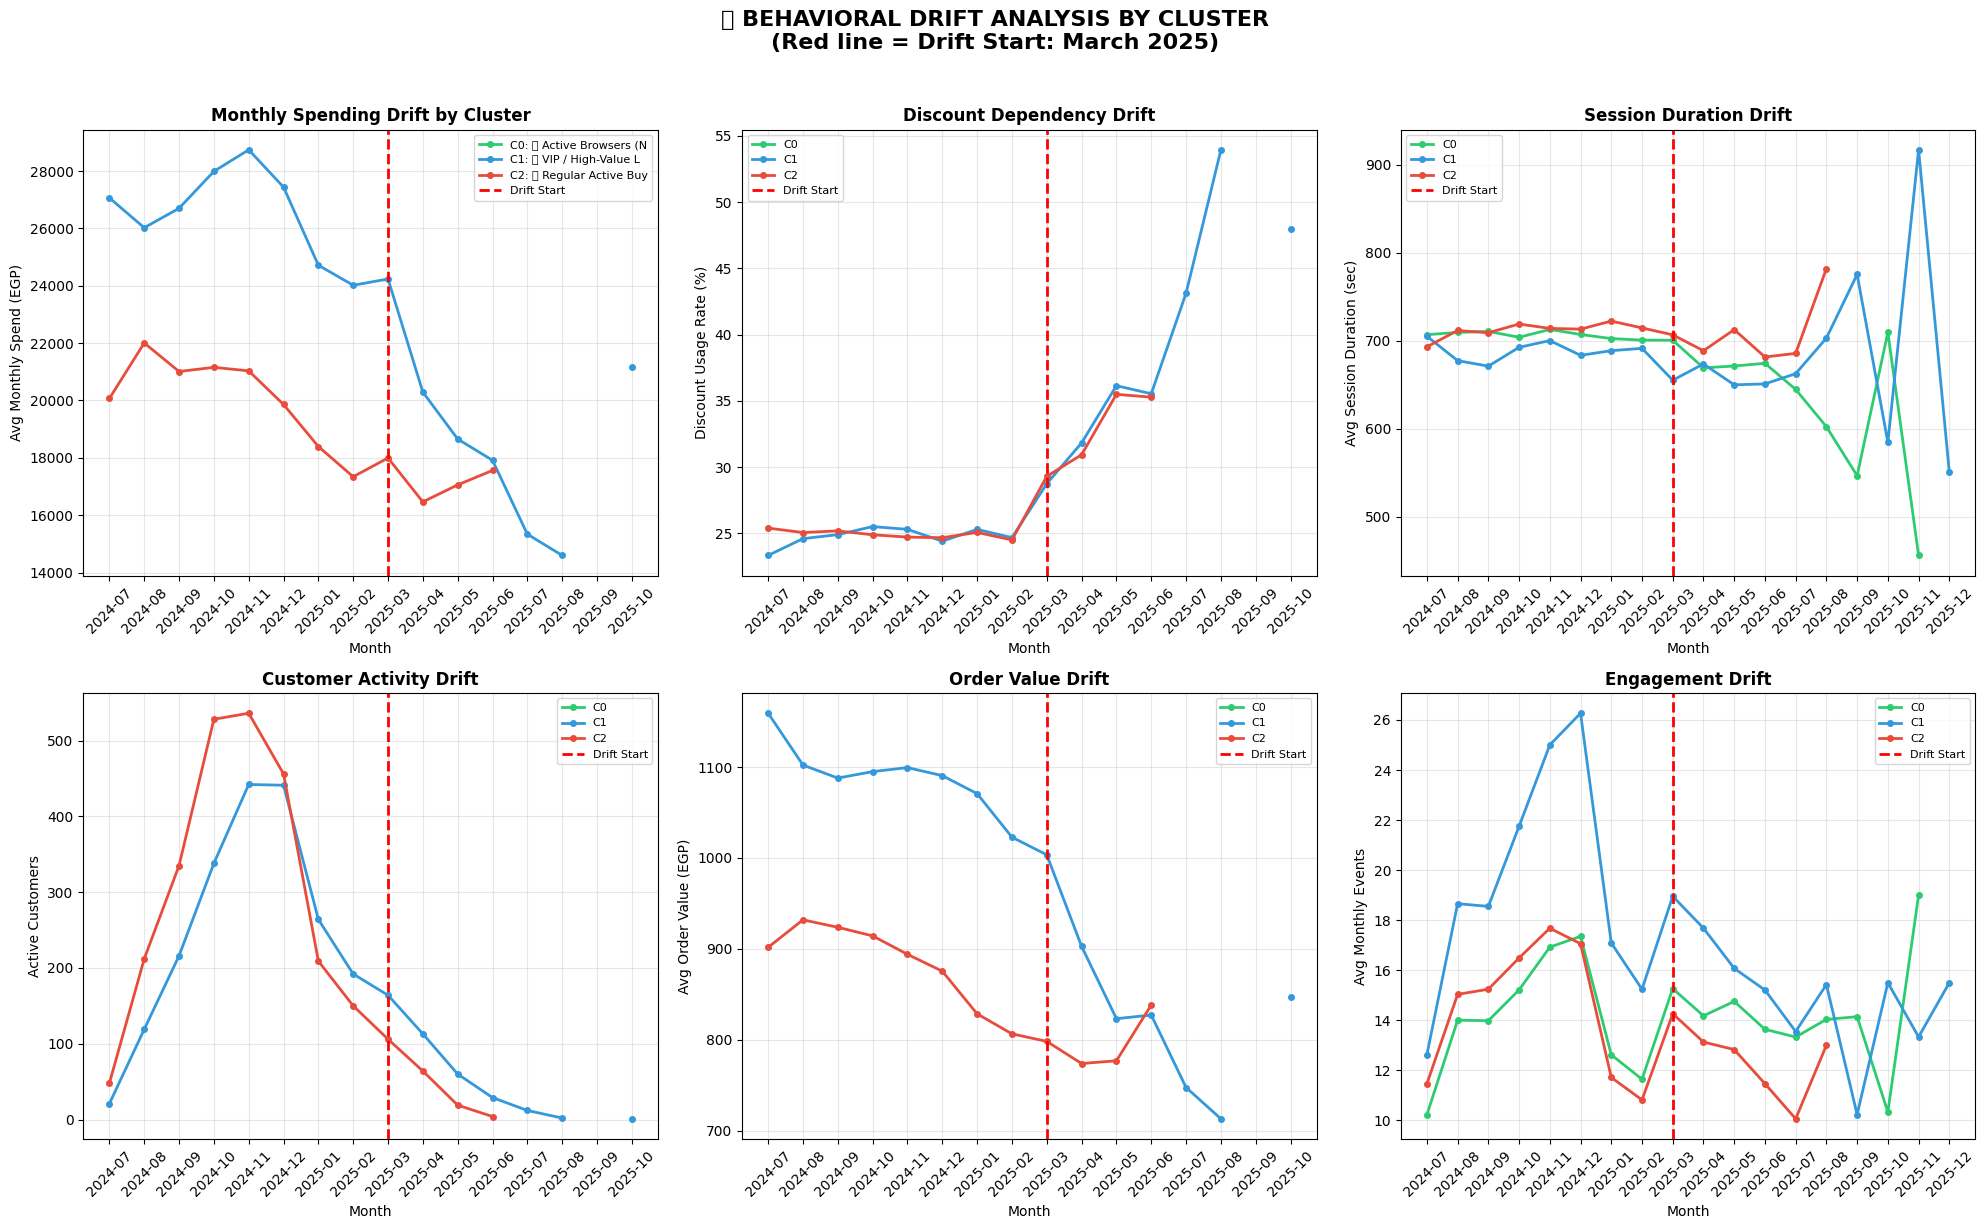


💡 DRIFT INTERPRETATION:
  - Red dashed line marks when behavioral drift began (Month 9)
  - Look for diverging trends AFTER the red line
  - Clusters showing steeper changes are most affected by drift


In [31]:
# =====================================================
# STEP 19: CLUSTER DRIFT VISUALIZATION
# =====================================================

# Aggregate metrics by month and cluster
monthly_cluster_orders = monthly_orders.groupby(['month', 'cluster']).agg({
    'monthly_spent': 'mean',
    'monthly_orders': 'mean',
    'avg_order_value': 'mean',
    'discount_rate': 'mean',
    'customer_id': 'nunique'  # Active customers
}).reset_index()
monthly_cluster_orders.columns = ['month', 'cluster', 'avg_monthly_spent', 'avg_orders', 
                                   'avg_order_value', 'discount_rate', 'active_customers']

monthly_cluster_events = monthly_events.groupby(['month', 'cluster']).agg({
    'monthly_events': 'mean',
    'avg_session_duration': 'mean'
}).reset_index()

# Merge
monthly_metrics = monthly_cluster_orders.merge(monthly_cluster_events, on=['month', 'cluster'], how='outer')

# Create drift visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Colors for clusters
colors = ['#2ecc71', '#3498db', '#e74c3c']
cluster_names = {i: segment_df[segment_df['cluster'] == i]['segment_name'].values[0][:20] 
                 for i in range(OPTIMAL_K)}

# Add drift start line (month 9 = March 2025)
drift_start = '2025-03'

# 1. Average Monthly Spending by Cluster
ax = axes[0, 0]
for cluster_id in range(OPTIMAL_K):
    data = monthly_metrics[monthly_metrics['cluster'] == cluster_id].sort_values('month')
    ax.plot(data['month'], data['avg_monthly_spent'], 'o-', 
            color=colors[cluster_id], linewidth=2, markersize=4,
            label=f'C{cluster_id}: {cluster_names[cluster_id]}')
ax.axvline(x=drift_start, color='red', linestyle='--', linewidth=2, label='Drift Start')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Monthly Spend (EGP)')
ax.set_title('Monthly Spending Drift by Cluster', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

# 2. Discount Usage Rate Over Time
ax = axes[0, 1]
for cluster_id in range(OPTIMAL_K):
    data = monthly_metrics[monthly_metrics['cluster'] == cluster_id].sort_values('month')
    ax.plot(data['month'], data['discount_rate'] * 100, 'o-', 
            color=colors[cluster_id], linewidth=2, markersize=4,
            label=f'C{cluster_id}')
ax.axvline(x=drift_start, color='red', linestyle='--', linewidth=2, label='Drift Start')
ax.set_xlabel('Month')
ax.set_ylabel('Discount Usage Rate (%)')
ax.set_title('Discount Dependency Drift', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

# 3. Average Session Duration Over Time
ax = axes[0, 2]
for cluster_id in range(OPTIMAL_K):
    data = monthly_metrics[monthly_metrics['cluster'] == cluster_id].sort_values('month')
    ax.plot(data['month'], data['avg_session_duration'], 'o-', 
            color=colors[cluster_id], linewidth=2, markersize=4,
            label=f'C{cluster_id}')
ax.axvline(x=drift_start, color='red', linestyle='--', linewidth=2, label='Drift Start')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Session Duration (sec)')
ax.set_title('Session Duration Drift', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

# 4. Active Customers Over Time
ax = axes[1, 0]
for cluster_id in range(OPTIMAL_K):
    data = monthly_metrics[monthly_metrics['cluster'] == cluster_id].sort_values('month')
    ax.plot(data['month'], data['active_customers'], 'o-', 
            color=colors[cluster_id], linewidth=2, markersize=4,
            label=f'C{cluster_id}')
ax.axvline(x=drift_start, color='red', linestyle='--', linewidth=2, label='Drift Start')
ax.set_xlabel('Month')
ax.set_ylabel('Active Customers')
ax.set_title('Customer Activity Drift', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

# 5. Average Order Value Over Time
ax = axes[1, 1]
for cluster_id in range(OPTIMAL_K):
    data = monthly_metrics[monthly_metrics['cluster'] == cluster_id].sort_values('month')
    ax.plot(data['month'], data['avg_order_value'], 'o-', 
            color=colors[cluster_id], linewidth=2, markersize=4,
            label=f'C{cluster_id}')
ax.axvline(x=drift_start, color='red', linestyle='--', linewidth=2, label='Drift Start')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Order Value (EGP)')
ax.set_title('Order Value Drift', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

# 6. Average Monthly Events (Engagement)
ax = axes[1, 2]
for cluster_id in range(OPTIMAL_K):
    data = monthly_metrics[monthly_metrics['cluster'] == cluster_id].sort_values('month')
    ax.plot(data['month'], data['monthly_events'], 'o-', 
            color=colors[cluster_id], linewidth=2, markersize=4,
            label=f'C{cluster_id}')
ax.axvline(x=drift_start, color='red', linestyle='--', linewidth=2, label='Drift Start')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Monthly Events')
ax.set_title('Engagement Drift', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

plt.suptitle('📈 BEHAVIORAL DRIFT ANALYSIS BY CLUSTER\n(Red line = Drift Start: March 2025)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 DRIFT INTERPRETATION:")
print("  - Red dashed line marks when behavioral drift began (Month 9)")
print("  - Look for diverging trends AFTER the red line")
print("  - Clusters showing steeper changes are most affected by drift")

📊 PRE vs POST DRIFT COMPARISON
 Cluster              Segment  Pre-Drift Spend  Post-Drift Spend  Spend Change %  Pre-Drift Discount  Post-Drift Discount  Discount Change
       0 😴 Inactive / Low Eng              NaN               NaN            0.00                 NaN                  NaN              NaN
       1 💎 VIP / High-Value L         26585.69          18886.41          -28.96               24.75                39.61            14.87
       2 🛒 Regular Active Buy         20109.47          17270.25          -14.12               24.93                32.75             7.82


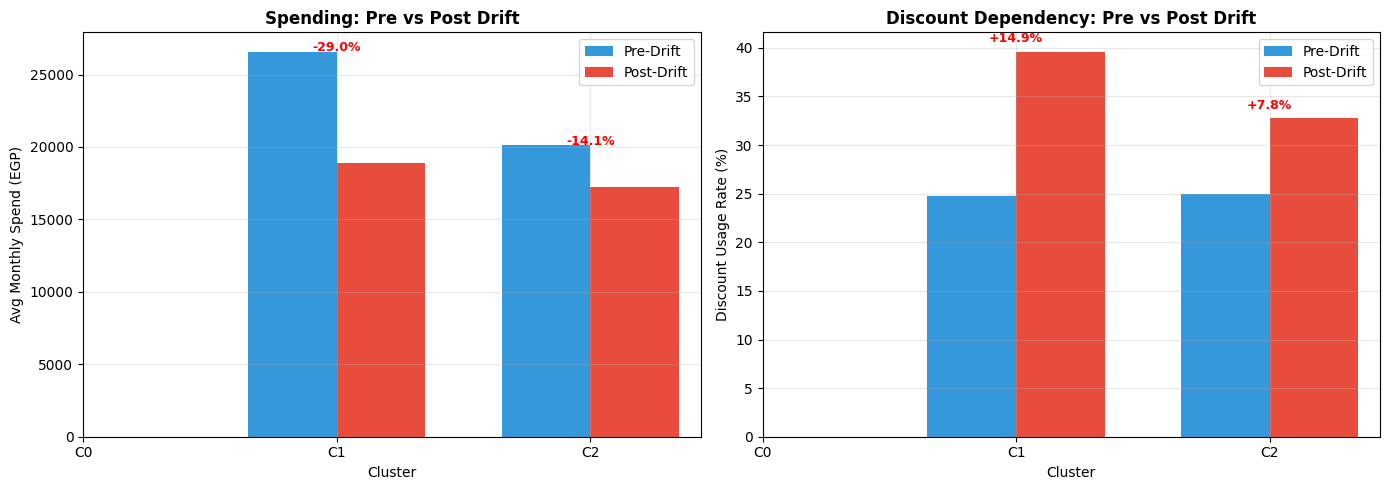


⚠️ KEY DRIFT FINDINGS:

  Cluster 0 (😴 Inactive / Low Eng):
    - Spending: 📈 INCREASED by 0.0%
    - Discount dependency: 📉 DECREASED by nan%

  Cluster 1 (💎 VIP / High-Value L):
    - Spending: 📉 DECREASED by 29.0%
    - Discount dependency: 📈 INCREASED by 14.9%

  Cluster 2 (🛒 Regular Active Buy):
    - Spending: 📉 DECREASED by 14.1%
    - Discount dependency: 📈 INCREASED by 7.8%


In [19]:
# =====================================================
# STEP 20: PRE vs POST DRIFT COMPARISON
# =====================================================

# Split data into pre-drift (before March 2025) and post-drift periods
pre_drift_months = monthly_metrics[monthly_metrics['month'] < '2025-03']
post_drift_months = monthly_metrics[monthly_metrics['month'] >= '2025-03']

# Calculate changes
drift_comparison = []

for cluster_id in range(OPTIMAL_K):
    pre = pre_drift_months[pre_drift_months['cluster'] == cluster_id]
    post = post_drift_months[post_drift_months['cluster'] == cluster_id]
    
    if len(pre) > 0 and len(post) > 0:
        drift_comparison.append({
            'Cluster': cluster_id,
            'Segment': cluster_names[cluster_id],
            'Pre-Drift Spend': pre['avg_monthly_spent'].mean(),
            'Post-Drift Spend': post['avg_monthly_spent'].mean(),
            'Spend Change %': ((post['avg_monthly_spent'].mean() - pre['avg_monthly_spent'].mean()) 
                               / pre['avg_monthly_spent'].mean() * 100) if pre['avg_monthly_spent'].mean() > 0 else 0,
            'Pre-Drift Discount': pre['discount_rate'].mean() * 100,
            'Post-Drift Discount': post['discount_rate'].mean() * 100,
            'Discount Change': (post['discount_rate'].mean() - pre['discount_rate'].mean()) * 100
        })

drift_df = pd.DataFrame(drift_comparison)

print("=" * 80)
print("📊 PRE vs POST DRIFT COMPARISON")
print("=" * 80)
print(drift_df.round(2).to_string(index=False))

# Visualize the change
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spending change
x = np.arange(len(drift_df))
width = 0.35
ax = axes[0]
bars1 = ax.bar(x - width/2, drift_df['Pre-Drift Spend'], width, label='Pre-Drift', color='#3498db')
bars2 = ax.bar(x + width/2, drift_df['Post-Drift Spend'], width, label='Post-Drift', color='#e74c3c')
ax.set_xlabel('Cluster')
ax.set_ylabel('Avg Monthly Spend (EGP)')
ax.set_title('Spending: Pre vs Post Drift', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'C{i}' for i in range(len(drift_df))])
ax.legend()
ax.grid(True, alpha=0.3)

# Add change percentage labels
for i, row in drift_df.iterrows():
    change = row['Spend Change %']
    color = 'red' if change < 0 else 'green'
    ax.annotate(f'{change:+.1f}%', xy=(i, max(row['Pre-Drift Spend'], row['Post-Drift Spend']) + 50),
                ha='center', fontsize=9, color=color, fontweight='bold')

# Discount change
ax = axes[1]
bars1 = ax.bar(x - width/2, drift_df['Pre-Drift Discount'], width, label='Pre-Drift', color='#3498db')
bars2 = ax.bar(x + width/2, drift_df['Post-Drift Discount'], width, label='Post-Drift', color='#e74c3c')
ax.set_xlabel('Cluster')
ax.set_ylabel('Discount Usage Rate (%)')
ax.set_title('Discount Dependency: Pre vs Post Drift', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'C{i}' for i in range(len(drift_df))])
ax.legend()
ax.grid(True, alpha=0.3)

# Add change labels
for i, row in drift_df.iterrows():
    change = row['Discount Change']
    color = 'red' if change > 0 else 'green'  # Higher discount = red (bad)
    ax.annotate(f'{change:+.1f}%', xy=(i, max(row['Pre-Drift Discount'], row['Post-Drift Discount']) + 1),
                ha='center', fontsize=9, color=color, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n⚠️ KEY DRIFT FINDINGS:")
for _, row in drift_df.iterrows():
    spend_change = row['Spend Change %']
    discount_change = row['Discount Change']
    print(f"\n  Cluster {int(row['Cluster'])} ({row['Segment']}):")
    print(f"    - Spending: {'📉 DECREASED' if spend_change < 0 else '📈 INCREASED'} by {abs(spend_change):.1f}%")
    print(f"    - Discount dependency: {'📈 INCREASED' if discount_change > 0 else '📉 DECREASED'} by {abs(discount_change):.1f}%")

🔍 AUTOMATIC DRIFT DETECTION METHODS

📊 METHOD 1: Rolling Z-Score Analysis
--------------------------------------------------
Drift detected in months: ['2024-11', '2025-01', '2025-02', '2025-04', '2025-05', '2025-07', '2025-08', '2025-10']

Z-scores by month:
  2024-07: z=0.00 
  2024-08: z=0.00 
  2024-09: z=0.47 
  2024-10: z=1.28 
  2024-11: z=3.43 ⚠️ DRIFT
  2024-12: z=-0.43 
  2025-01: z=-4.25 ⚠️ DRIFT
  2025-02: z=-1.71 ⚠️ DRIFT
  2025-03: z=-0.33 
  2025-04: z=-6.02 ⚠️ DRIFT
  2025-05: z=-1.55 ⚠️ DRIFT
  2025-06: z=-0.95 
  2025-07: z=-5.76 ⚠️ DRIFT
  2025-08: z=-1.61 ⚠️ DRIFT
  2025-10: z=3.04 ⚠️ DRIFT

📊 METHOD 2: Population Stability Index (PSI)
--------------------------------------------------
PSI (early vs late period): 0.1296
  ⚠️ MODERATE drift detected - monitor closely

📊 METHOD 3: Kolmogorov-Smirnov Test
--------------------------------------------------
KS Statistic: 0.1475
P-value: 0.0000
  🚨 Distributions are SIGNIFICANTLY different (drift confirmed)


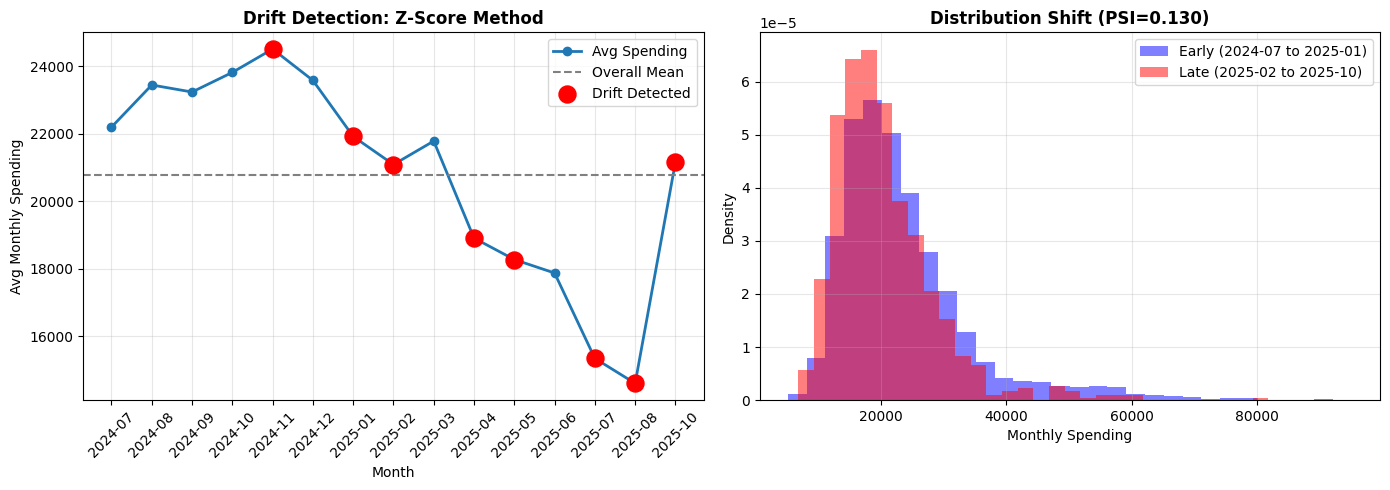


💡 DRIFT DETECTION SUMMARY

WHAT DECIDES DRIFT:
━━━━━━━━━━━━━━━━━━━
1. Z-Score > 1.5-2: Current value is unusually far from recent average
2. PSI > 0.25: Distribution shape has changed significantly  
3. KS Test p < 0.05: Statistical proof that distributions are different

WHAT DRIFT MEANS FOR BUSINESS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Customer behavior is changing (spending patterns, engagement, etc.)
• ML models trained on old data may become less accurate
• Marketing strategies may need adjustment
• Could indicate external factors (economy, competition, seasonality)

ACTIONS WHEN DRIFT DETECTED:
━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Investigate root cause (market changes, product changes, etc.)
2. Re-train ML models with recent data
3. Update customer segments
4. Adjust business strategies accordingly



In [20]:
# =====================================================
# STEP 21: AUTOMATIC DRIFT DETECTION (No Prior Knowledge)
# =====================================================
from scipy import stats

print("=" * 80)
print("🔍 AUTOMATIC DRIFT DETECTION METHODS")
print("=" * 80)

# Method 1: Rolling Z-Score Detection
# -----------------------------------
# If current month's value is >2 std from rolling mean, flag as drift

def detect_drift_zscore(series, window=3, threshold=2):
    """Detect drift using rolling z-score"""
    rolling_mean = series.rolling(window=window, min_periods=2).mean()
    rolling_std = series.rolling(window=window, min_periods=2).std()
    z_scores = (series - rolling_mean.shift(1)) / rolling_std.shift(1)
    drift_points = z_scores.abs() > threshold
    return drift_points, z_scores

# Method 2: Population Stability Index (PSI)
# ------------------------------------------
# PSI > 0.1 = slight drift, PSI > 0.25 = significant drift

def calculate_psi(expected, actual, buckets=10):
    """Calculate PSI between two distributions"""
    def psi_values(exp_pct, act_pct):
        psi = (act_pct - exp_pct) * np.log(act_pct / exp_pct)
        return psi
    
    # Create buckets based on expected distribution
    breakpoints = np.percentile(expected, np.linspace(0, 100, buckets + 1))
    breakpoints = np.unique(breakpoints)
    
    exp_counts = np.histogram(expected, breakpoints)[0] + 1  # Add 1 to avoid division by zero
    act_counts = np.histogram(actual, breakpoints)[0] + 1
    
    exp_pct = exp_counts / exp_counts.sum()
    act_pct = act_counts / act_counts.sum()
    
    return np.sum(psi_values(exp_pct, act_pct))

# Apply drift detection to our data
print("\n📊 METHOD 1: Rolling Z-Score Analysis")
print("-" * 50)

# Aggregate monthly spending across all customers (not by cluster)
monthly_overall = monthly_orders.groupby('month').agg({
    'monthly_spent': 'mean',
    'discount_rate': 'mean'
}).reset_index().sort_values('month')

# Detect drift points
drift_mask, z_scores = detect_drift_zscore(monthly_overall['monthly_spent'], window=3, threshold=1.5)
drift_months = monthly_overall[drift_mask]['month'].tolist()

print(f"Drift detected in months: {drift_months if drift_months else 'None'}")
print(f"\nZ-scores by month:")
for i, row in monthly_overall.iterrows():
    z = z_scores.iloc[i] if not pd.isna(z_scores.iloc[i]) else 0
    flag = "⚠️ DRIFT" if abs(z) > 1.5 else ""
    print(f"  {row['month']}: z={z:.2f} {flag}")

# Method 2: PSI Comparison
print("\n📊 METHOD 2: Population Stability Index (PSI)")
print("-" * 50)

# Compare first 6 months vs last 6 months
months = sorted(monthly_orders['month'].unique())
mid_point = len(months) // 2
early_months = months[:mid_point]
late_months = months[mid_point:]

early_data = monthly_orders[monthly_orders['month'].isin(early_months)]['monthly_spent']
late_data = monthly_orders[monthly_orders['month'].isin(late_months)]['monthly_spent']

if len(early_data) > 10 and len(late_data) > 10:
    psi = calculate_psi(early_data.values, late_data.values)
    print(f"PSI (early vs late period): {psi:.4f}")
    if psi < 0.1:
        print("  ✅ No significant drift detected")
    elif psi < 0.25:
        print("  ⚠️ MODERATE drift detected - monitor closely")
    else:
        print("  🚨 SIGNIFICANT drift detected - action required!")

# Method 3: Statistical Test (Kolmogorov-Smirnov)
print("\n📊 METHOD 3: Kolmogorov-Smirnov Test")
print("-" * 50)

ks_stat, p_value = stats.ks_2samp(early_data, late_data)
print(f"KS Statistic: {ks_stat:.4f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("  🚨 Distributions are SIGNIFICANTLY different (drift confirmed)")
else:
    print("  ✅ No statistically significant drift")

# Visualize drift detection
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Z-Score over time
ax = axes[0]
ax.plot(monthly_overall['month'], monthly_overall['monthly_spent'], 'o-', linewidth=2, label='Avg Spending')
ax.axhline(y=monthly_overall['monthly_spent'].mean(), color='gray', linestyle='--', label='Overall Mean')

# Highlight drift points
drift_data = monthly_overall[drift_mask]
ax.scatter(drift_data['month'], drift_data['monthly_spent'], color='red', s=150, zorder=5, label='Drift Detected')

ax.set_xlabel('Month')
ax.set_ylabel('Avg Monthly Spending')
ax.set_title('Drift Detection: Z-Score Method', fontsize=12, fontweight='bold')
ax.legend()
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

# Plot 2: Distribution comparison
ax = axes[1]
ax.hist(early_data, bins=30, alpha=0.5, label=f'Early ({early_months[0]} to {early_months[-1]})', color='blue', density=True)
ax.hist(late_data, bins=30, alpha=0.5, label=f'Late ({late_months[0]} to {late_months[-1]})', color='red', density=True)
ax.set_xlabel('Monthly Spending')
ax.set_ylabel('Density')
ax.set_title(f'Distribution Shift (PSI={psi:.3f})', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("💡 DRIFT DETECTION SUMMARY")
print("=" * 80)
print("""
WHAT DECIDES DRIFT:
━━━━━━━━━━━━━━━━━━━
1. Z-Score > 1.5-2: Current value is unusually far from recent average
2. PSI > 0.25: Distribution shape has changed significantly  
3. KS Test p < 0.05: Statistical proof that distributions are different

WHAT DRIFT MEANS FOR BUSINESS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Customer behavior is changing (spending patterns, engagement, etc.)
• ML models trained on old data may become less accurate
• Marketing strategies may need adjustment
• Could indicate external factors (economy, competition, seasonality)

ACTIONS WHEN DRIFT DETECTED:
━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Investigate root cause (market changes, product changes, etc.)
2. Re-train ML models with recent data
3. Update customer segments
4. Adjust business strategies accordingly
""")

⚠️ VIP MIGRATION / CHURN RISK ANALYSIS

📌 Cluster 0: 👀 Active Browsers (Non-Buyers)
   → No purchases - skip recency risk analysis

📌 Cluster 1: 💎 VIP / High-Value Loyal
   Avg Tenure: 517 days
   Avg Orders: 36.3
   Expected Purchase Gap: 14.3 days
   Actual Avg Recency: 403 days
   Risk Ratio: 28.2x (recency / expected gap)

   🟡 At-Risk (>2x gap): 1,448 customers (100.0%)
   🔴 High-Risk (>5x gap): 1,445 customers (99.8%)

   🚨 ALERT: Avg recency is 28.2x the expected purchase gap!
   → Immediate retention campaign needed

📌 Cluster 2: 🛒 Regular Active Buyers
   Avg Tenure: 522 days
   Avg Orders: 24.1
   Expected Purchase Gap: 21.7 days
   Actual Avg Recency: 447 days
   Risk Ratio: 20.6x (recency / expected gap)

   🟡 At-Risk (>2x gap): 2,233 customers (100.0%)
   🔴 High-Risk (>5x gap): 2,233 customers (100.0%)

   🚨 ALERT: Avg recency is 20.6x the expected purchase gap!
   → Immediate retention campaign needed


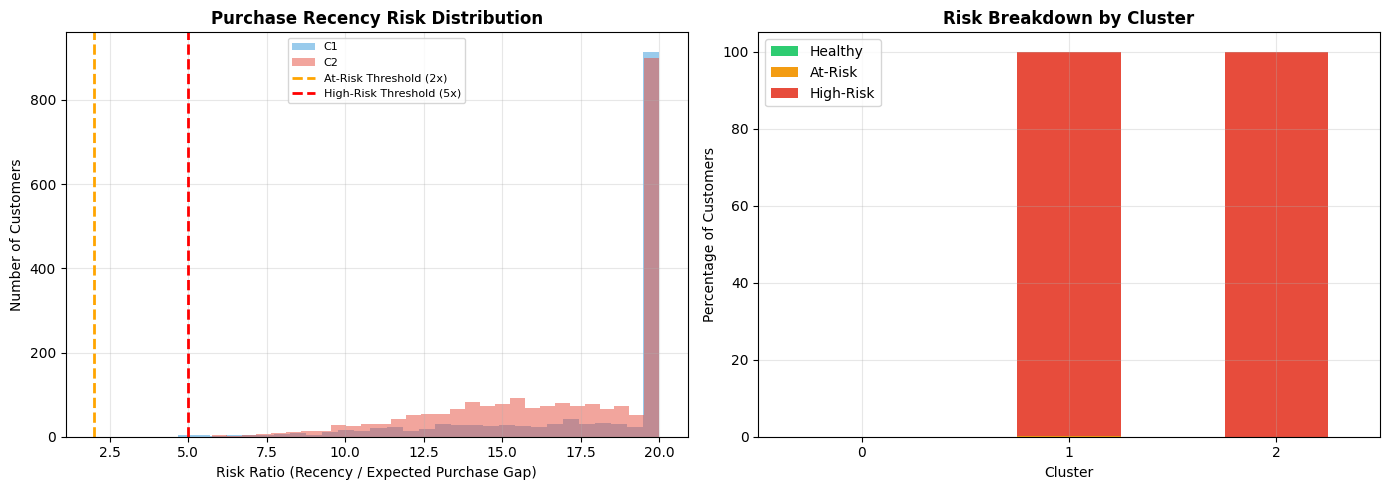


💡 RISK RATIO INTERPRETATION:
  Risk Ratio = Days Since Last Purchase / Expected Gap Between Purchases
  • ≤ 2x: Healthy (within normal buying cycle)
  • 2x-5x: At-Risk (overdue for purchase)
  • > 5x: High-Risk (likely churned or churning)


In [32]:
# =====================================================
# STEP 22: VIP MIGRATION RISK ANALYSIS
# =====================================================

print("=" * 80)
print("⚠️ VIP MIGRATION / CHURN RISK ANALYSIS")
print("=" * 80)

# Analyze each cluster's recency vs purchase frequency
for cluster_id in range(OPTIMAL_K):
    cluster_data = df[df['cluster'] == cluster_id]
    segment = segment_df[segment_df['cluster'] == cluster_id]['segment_name'].values[0]
    
    # Calculate expected purchase gap (tenure / orders)
    buyers = cluster_data[cluster_data['orders_count'].fillna(0) > 0]
    
    if len(buyers) == 0:
        print(f"\n📌 Cluster {cluster_id}: {segment}")
        print(f"   → No purchases - skip recency risk analysis")
        continue
    
    avg_tenure = buyers['customer_tenure_days'].mean()
    avg_orders = buyers['orders_count'].mean()
    avg_recency = buyers['days_since_last_purchase'].mean()
    expected_gap = avg_tenure / avg_orders  # Expected days between orders
    
    # Risk ratio: how many times longer than expected since last purchase
    risk_ratio = avg_recency / expected_gap if expected_gap > 0 else 0
    
    # Individual risk assessment
    buyers_copy = buyers.copy()
    buyers_copy['expected_gap'] = buyers_copy['customer_tenure_days'] / buyers_copy['orders_count']
    buyers_copy['risk_ratio'] = buyers_copy['days_since_last_purchase'] / buyers_copy['expected_gap']
    
    at_risk = (buyers_copy['risk_ratio'] > 2).sum()  # >2x their normal gap
    high_risk = (buyers_copy['risk_ratio'] > 5).sum()  # >5x = very overdue
    
    print(f"\n{'='*60}")
    print(f"📌 Cluster {cluster_id}: {segment}")
    print(f"{'='*60}")
    print(f"   Avg Tenure: {avg_tenure:.0f} days")
    print(f"   Avg Orders: {avg_orders:.1f}")
    print(f"   Expected Purchase Gap: {expected_gap:.1f} days")
    print(f"   Actual Avg Recency: {avg_recency:.0f} days")
    print(f"   Risk Ratio: {risk_ratio:.1f}x (recency / expected gap)")
    print(f"")
    print(f"   🟡 At-Risk (>2x gap): {at_risk:,} customers ({at_risk/len(buyers)*100:.1f}%)")
    print(f"   🔴 High-Risk (>5x gap): {high_risk:,} customers ({high_risk/len(buyers)*100:.1f}%)")
    
    if risk_ratio > 3:
        print(f"\n   🚨 ALERT: Avg recency is {risk_ratio:.1f}x the expected purchase gap!")
        print(f"   → Immediate retention campaign needed")
    elif risk_ratio > 1.5:
        print(f"\n   ⚠️ WARNING: Customers are buying slower than expected")
        print(f"   → Monitor and prepare win-back strategy")
    else:
        print(f"\n   ✅ HEALTHY: Purchase frequency within expected range")

# Visualize risk distribution for VIP cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Risk ratio distribution per cluster
for cluster_id in range(OPTIMAL_K):
    cluster_buyers = df[(df['cluster'] == cluster_id) & (df['orders_count'].fillna(0) > 0)].copy()
    if len(cluster_buyers) == 0:
        continue
    cluster_buyers['expected_gap'] = cluster_buyers['customer_tenure_days'] / cluster_buyers['orders_count']
    cluster_buyers['risk_ratio'] = cluster_buyers['days_since_last_purchase'] / cluster_buyers['expected_gap']
    # Cap for visualization
    cluster_buyers['risk_ratio_capped'] = cluster_buyers['risk_ratio'].clip(upper=20)
    
    axes[0].hist(cluster_buyers['risk_ratio_capped'], bins=30, alpha=0.5, 
                 label=f'C{cluster_id}', color=['#2ecc71', '#3498db', '#e74c3c'][cluster_id])

axes[0].axvline(x=2, color='orange', linestyle='--', linewidth=2, label='At-Risk Threshold (2x)')
axes[0].axvline(x=5, color='red', linestyle='--', linewidth=2, label='High-Risk Threshold (5x)')
axes[0].set_xlabel('Risk Ratio (Recency / Expected Purchase Gap)')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Purchase Recency Risk Distribution', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Plot 2: Risk breakdown per cluster (stacked bar)
risk_data = []
for cluster_id in range(OPTIMAL_K):
    cluster_buyers = df[(df['cluster'] == cluster_id) & (df['orders_count'].fillna(0) > 0)].copy()
    if len(cluster_buyers) == 0:
        risk_data.append({'cluster': cluster_id, 'Healthy': 0, 'At-Risk': 0, 'High-Risk': 0})
        continue
    cluster_buyers['expected_gap'] = cluster_buyers['customer_tenure_days'] / cluster_buyers['orders_count']
    cluster_buyers['risk_ratio'] = cluster_buyers['days_since_last_purchase'] / cluster_buyers['expected_gap']
    
    healthy = (cluster_buyers['risk_ratio'] <= 2).sum()
    at_risk = ((cluster_buyers['risk_ratio'] > 2) & (cluster_buyers['risk_ratio'] <= 5)).sum()
    high_risk = (cluster_buyers['risk_ratio'] > 5).sum()
    total = len(cluster_buyers)
    
    risk_data.append({
        'cluster': cluster_id,
        'Healthy': healthy / total * 100,
        'At-Risk': at_risk / total * 100,
        'High-Risk': high_risk / total * 100
    })

risk_df = pd.DataFrame(risk_data)
risk_df.set_index('cluster')[['Healthy', 'At-Risk', 'High-Risk']].plot(
    kind='bar', stacked=True, ax=axes[1],
    color=['#2ecc71', '#f39c12', '#e74c3c']
)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Percentage of Customers')
axes[1].set_title('Risk Breakdown by Cluster', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 RISK RATIO INTERPRETATION:")
print("  Risk Ratio = Days Since Last Purchase / Expected Gap Between Purchases")
print("  • ≤ 2x: Healthy (within normal buying cycle)")
print("  • 2x-5x: At-Risk (overdue for purchase)")
print("  • > 5x: High-Risk (likely churned or churning)")

📊 STATISTICAL SIGNIFICANCE TESTS
Testing whether cluster differences are statistically real (not random chance)

TEST 1: ONE-WAY ANOVA (Numeric Features)
H0: All cluster means are equal
H1: At least one cluster mean is different
Rule: p-value < 0.05 → Reject H0 → Clusters ARE different

                 Feature  F-Statistic   P-Value Significant?
             total_spent       964.41 2.97e-188        ✅ YES
            orders_count       620.15 1.23e-126        ✅ YES
         avg_order_value       744.50 1.90e-149        ✅ YES
days_since_last_purchase       395.31  1.23e-83        ✅ YES
    avg_session_duration        18.07  1.49e-08        ✅ YES
     discount_usage_rate         8.44    0.0037        ✅ YES
            total_events      2957.29  0.00e+00        ✅ YES
         purchase_events      7811.49  0.00e+00        ✅ YES

📋 Result: 8/8 features show SIGNIFICANT differences between clusters

TEST 2: CHI-SQUARE TEST (Categorical Features)
H0: Category distribution is same across clus

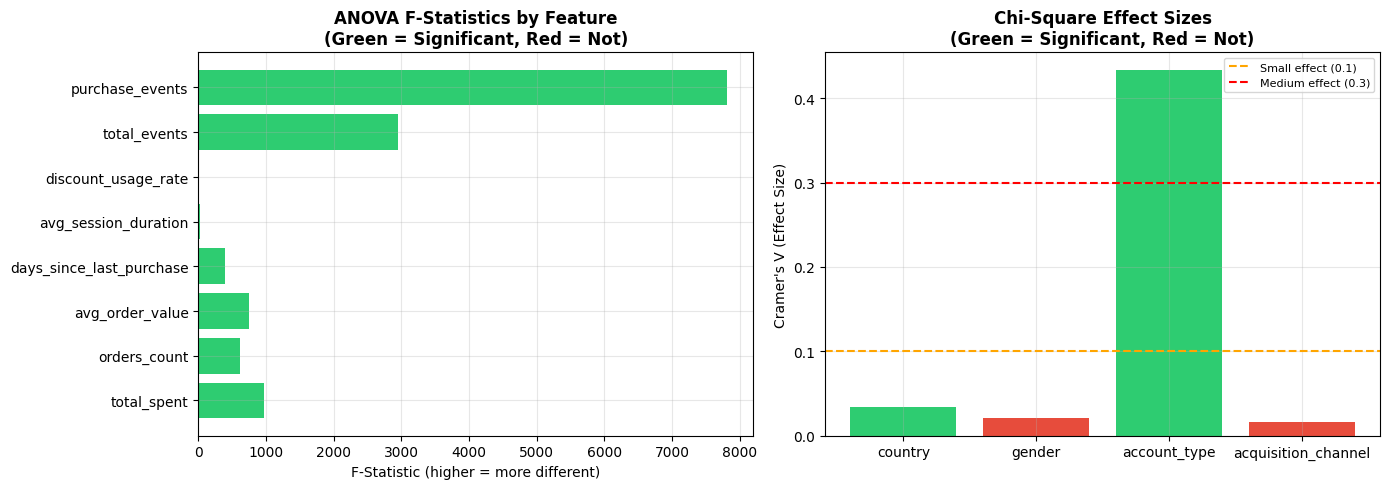


💡 INTERPRETATION GUIDE

ANOVA:
  - Tests if NUMERIC features (spending, orders, etc.) differ across clusters
  - High F-stat + low p-value = Clusters are truly different on that feature
  - All significant = Our clusters capture REAL behavioral differences

CHI-SQUARE:
  - Tests if CATEGORICAL features (gender, country, etc.) differ across clusters  
  - Cramer's V shows effect size: <0.1 small, 0.1-0.3 medium, >0.3 large
  - Low Cramer's V confirms: Demographics DON'T drive segmentation (behavior does)

MANN-WHITNEY U:
  - Pairwise: tells us WHICH specific clusters differ from each other
  - Non-parametric (doesn't assume normal distribution)



In [33]:
# =====================================================
# STEP 23: STATISTICAL SIGNIFICANCE BETWEEN CLUSTERS
# =====================================================
from scipy import stats

print("=" * 80)
print("📊 STATISTICAL SIGNIFICANCE TESTS")
print("=" * 80)
print("Testing whether cluster differences are statistically real (not random chance)")

# ─────────────────────────────────────────────────
# 1. ANOVA TEST (Numeric Features: Are means truly different?)
# ─────────────────────────────────────────────────
print("\n" + "=" * 60)
print("TEST 1: ONE-WAY ANOVA (Numeric Features)")
print("=" * 60)
print("H0: All cluster means are equal")
print("H1: At least one cluster mean is different")
print("Rule: p-value < 0.05 → Reject H0 → Clusters ARE different\n")

anova_features = ['total_spent', 'orders_count', 'avg_order_value', 
                  'days_since_last_purchase', 'avg_session_duration',
                  'discount_usage_rate', 'total_events', 'purchase_events']

anova_results = []
for feature in anova_features:
    groups = []
    for cluster_id in range(OPTIMAL_K):
        cluster_data = df[df['cluster'] == cluster_id][feature].dropna()
        if len(cluster_data) > 0:
            groups.append(cluster_data)
    
    if len(groups) >= 2:
        f_stat, p_value = stats.f_oneway(*groups)
        significant = "✅ YES" if p_value < 0.05 else "❌ NO"
        anova_results.append({
            'Feature': feature,
            'F-Statistic': round(f_stat, 2),
            'P-Value': f'{p_value:.2e}' if p_value < 0.001 else f'{p_value:.4f}',
            'Significant?': significant
        })
        
anova_df = pd.DataFrame(anova_results)
print(anova_df.to_string(index=False))

sig_count = sum(1 for r in anova_results if "YES" in r['Significant?'])
print(f"\n📋 Result: {sig_count}/{len(anova_results)} features show SIGNIFICANT differences between clusters")

# ─────────────────────────────────────────────────
# 2. CHI-SQUARE TEST (Categorical: Are distributions different?)
# ─────────────────────────────────────────────────
print("\n" + "=" * 60)
print("TEST 2: CHI-SQUARE TEST (Categorical Features)")
print("=" * 60)
print("H0: Category distribution is same across clusters")
print("H1: Category distribution differs across clusters")
print("Rule: p-value < 0.05 → Reject H0 → Distributions ARE different\n")

categorical_features = ['country', 'gender', 'account_type', 'acquisition_channel']

chi2_results = []
for feature in categorical_features:
    contingency = pd.crosstab(df['cluster'], df[feature])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    
    significant = "✅ YES" if p_value < 0.05 else "❌ NO"
    effect_size = np.sqrt(chi2 / (len(df) * (min(contingency.shape) - 1)))  # Cramer's V
    
    chi2_results.append({
        'Feature': feature,
        'Chi-Square': round(chi2, 2),
        'P-Value': f'{p_value:.2e}' if p_value < 0.001 else f'{p_value:.4f}',
        "Cramer's V": round(effect_size, 4),
        'Effect Size': 'Small' if effect_size < 0.1 else ('Medium' if effect_size < 0.3 else 'Large'),
        'Significant?': significant
    })

chi2_df = pd.DataFrame(chi2_results)
print(chi2_df.to_string(index=False))

# ─────────────────────────────────────────────────
# 3. PAIRWISE POST-HOC TESTS (Which clusters differ from which?)
# ─────────────────────────────────────────────────
print("\n" + "=" * 60)
print("TEST 3: PAIRWISE COMPARISON (Mann-Whitney U)")
print("=" * 60)
print("Compares each pair of clusters to see which ones differ\n")

key_features = ['total_spent', 'orders_count', 'avg_session_duration']

for feature in key_features:
    print(f"\n📊 {feature}:")
    for i in range(OPTIMAL_K):
        for j in range(i+1, OPTIMAL_K):
            data_i = df[df['cluster'] == i][feature].dropna()
            data_j = df[df['cluster'] == j][feature].dropna()
            
            if len(data_i) > 0 and len(data_j) > 0:
                stat, p_value = stats.mannwhitneyu(data_i, data_j, alternative='two-sided')
                sig = "✅ Different" if p_value < 0.05 else "❌ Not different"
                print(f"   C{i} vs C{j}: p={p_value:.4e} → {sig}")

# ─────────────────────────────────────────────────
# VISUAL SUMMARY
# ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: ANOVA F-statistics
f_stats = [float(r['F-Statistic']) for r in anova_results]
feat_names = [r['Feature'] for r in anova_results]
bar_colors = ['#2ecc71' if 'YES' in r['Significant?'] else '#e74c3c' for r in anova_results]

axes[0].barh(feat_names, f_stats, color=bar_colors)
axes[0].set_xlabel('F-Statistic (higher = more different)')
axes[0].set_title('ANOVA F-Statistics by Feature\n(Green = Significant, Red = Not)', 
                   fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: Chi-Square + Cramer's V for categorical
cat_names = [r['Feature'] for r in chi2_results]
cramers_v = [r["Cramer's V"] for r in chi2_results]
cat_colors = ['#2ecc71' if 'YES' in r['Significant?'] else '#e74c3c' for r in chi2_results]

bars = axes[1].bar(cat_names, cramers_v, color=cat_colors)
axes[1].axhline(y=0.1, color='orange', linestyle='--', label='Small effect (0.1)')
axes[1].axhline(y=0.3, color='red', linestyle='--', label='Medium effect (0.3)')
axes[1].set_ylabel("Cramer's V (Effect Size)")
axes[1].set_title("Chi-Square Effect Sizes\n(Green = Significant, Red = Not)", 
                   fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("💡 INTERPRETATION GUIDE")
print("=" * 80)
print("""
ANOVA:
  - Tests if NUMERIC features (spending, orders, etc.) differ across clusters
  - High F-stat + low p-value = Clusters are truly different on that feature
  - All significant = Our clusters capture REAL behavioral differences

CHI-SQUARE:
  - Tests if CATEGORICAL features (gender, country, etc.) differ across clusters  
  - Cramer's V shows effect size: <0.1 small, 0.1-0.3 medium, >0.3 large
  - Low Cramer's V confirms: Demographics DON'T drive segmentation (behavior does)

MANN-WHITNEY U:
  - Pairwise: tells us WHICH specific clusters differ from each other
  - Non-parametric (doesn't assume normal distribution)
""")